# Pita / Carvalho Antifer geometry notebook

This notebook calculates, validates, visualises and exports one vectorial Antifer armour-unit solid directly from notebook cells.

Implemented geometry conventions:

- **Pita (1986)**: historical Antifer dimensional convention represented by the adopted non-dimensional proportions and by the exact circular-segment geometric volume coefficient \(V/H^3 = 1.024700000000\).
- **Carvalho (2026)**: volume-normalised Antifer coefficient convention using the same vectorial topology, lateral chamfer convention and circular-arc groove formulation, with geometric volume coefficient \(V/H^3 = 1.000000\).

Notebook workflow:

1. Edit the **USER INPUTS** cell.
2. Run the production core cell.
3. Run the report and visualisation cells.
4. Run the export cell to write IFC, STL, OBJ, DXF and `output.txt` to `OUTPUT_FOLDER`.

Geometry convention used by the notebook:

- two homologous horizontal sections, bottom at `z = 0` and top at `z = H`;
- no top bevel;
- `B` measured directly at the top plane `z = H`;
- four lateral plan chamfers;
- four identical circular-arc grooves;
- exported XY origin at the homogeneous centre of mass;
- exported Z origin at the physical bottom level.

The B-rep uses the fixed production arc resolution and an area-preserving groove sampling so that both Pita and Carvalho B-rep volumes match their governing geometric volume coefficients without increasing `GROOVE_ARC_POINTS`.

Full CAD/BIM export uses `ezdxf` and `trimesh`. In a notebook kernel, install missing packages with:

```python
%pip install ezdxf trimesh pillow
```

The notebook is run cell-by-cell in the active kernel; exported files are written by the final export cell.


In [1]:
# =============================================================================
# USER INPUTS
# =============================================================================

# Choose one of: "pita_1986" or "carvalho_2026"
GEOMETRY_PROFILE = "pita_1986"

# Unit force and concrete unit weight
W_kN = 680.0
Wc_kN_m3 = 27.20

# Output folder for IFC + STL + OBJ + DXF + output.txt
# The folder is created automatically if it does not exist.
OUTPUT_FOLDER = "antifer_notebook_output"

# Production value. Keep 144 to reproduce the calibrated production geometry.
GROOVE_ARC_POINTS = 144


In [2]:
# =============================================================================
# NOTEBOOK PRODUCTION CORE — GEOMETRY AND EXPORT ROUTINES
# =============================================================================

#!/usr/bin/env python3
"""
Vectorial Antifer armour-unit notebook core
-------------------------------------------

Notebook-oriented calculation, validation, visualisation and export core for one
Antifer concrete armour unit. This cell is intended to be run inside Jupyter,
VS Code notebooks, or another standard IPython notebook environment.

The notebook converts a specified unit weight W [kN] and concrete unit weight
Wc [kN/m³] into a dimensionally defined Antifer solid using one of two
selectable dimensional conventions:

    - Pita (1986), represented by the adopted historical dimensional ratios
      and by a calibrated single circular-arc groove construction;
    - Carvalho (2026), represented as a volume-normalised coefficient
      convention using the same vectorial topology and groove construction.

The selected convention controls the volumetric coefficient, proportional
coefficients, generated boundary-representation and exported IFC/STL/OBJ/DXF
files. The convention is selected in the USER INPUTS cell by setting
GEOMETRY_PROFILE to either "pita_1986" or "carvalho_2026".

This notebook deliberately avoids embedded template geometry. No pre-existing
DXF, SAT, ACIS, RFA, IFC or binary template solid is inserted or decoded. The
Antifer solid is generated from numerical coefficients by a vectorial geometric
procedure.

Notebook objectives
    - Calculate the Antifer block volume from W / Wc.
    - Select Pita (1986) or Carvalho (2026) through the GEOMETRY_PROFILE input.
    - Derive H, A, B, C, D, R, E and q from the active convention.
    - Generate a closed vectorial boundary-representation directly in memory.
    - Translate the final B-rep so the exported XY origin is at the homogeneous
      centre of mass, while the exported Z datum remains the physical bottom
      level z = 0.
    - Visualise the solid in the notebook with equal XYZ scale and a solid
      shaded viewer.
    - Export matching IFC, STL, OBJ and DXF deliverables from the same validated
      B-rep.
    - Write output.txt with the same fixed-width calculation and validation
      report shown in the notebook report window.

Notebook capabilities
    - Calculates the Antifer unit volume from W / Wc and derives the full
      geometric parameter set: H, A, B, C, D, R, E, q and the main lateral angle.
    - Uses explicit non-dimensional coefficients derived from the active
      convention and reports values with fixed engineering precision.
    - Builds the Antifer geometry as a closed polygonal B-rep with two
      homologous horizontal sections: lower construction section at z = 0 with
      width A and flat top construction section at z = H with width B.
    - Generates four lateral grooves as single circular arcs of absolute
      radius R. The dimensionless groove-radius coefficient is r = R/H.
    - Uses the exact top and bottom boundary loops as the production B-rep
      source. IFC writes the exact cap loops as IFC4 FacetedBrep faces. STL and
      OBJ are written from a validated triangular export mesh. DXF uses the same
      ACIS-backed 3DSOLID export path as the production Python generator when
      the required packages are available.
    - Validates closed-shell topology by checking that each B-rep edge is shared
      by exactly two faces.
    - Computes geometric metadata such as volume, centre of mass, surface area,
      bounding-box dimensions, lateral-facet angle, vertex count, face count and
      section discretisation.
    - Provides two notebook visualisation modes: Matplotlib 3D with equal XYZ
      scale and a native HTML/Canvas viewer with solid shaded faces, rotation,
      zoom and pan.

Main functions
    calculate_dimensions(W_kN, Wc_kN_m3, profile)
        Converts the Antifer weight W and concrete unit weight Wc into volume
        and geometric dimensions using the selected convention.

    generate_antifer_brep(W_kN, Wc_kN_m3, profile)
        Builds the complete closed B-rep, validates topology, verifies the
        groove-radius relation, translates the vertices to the XY centre-of-mass
        and bottom-Z datum convention, and returns the geometric data used by
        the notebook visualisation and export cells.

    write_ifc_file(filepath, brep, include_properties=True)
        Writes the production B-rep loops to IFC4 using IfcFacetedBrep geometry
        and includes calculation values, dimensional coefficients, validation
        results and geometric metadata in IFC property and quantity sets.

    write_dxf_file(filepath, brep)
        Writes the validated Antifer geometry to DXF using the production
        ACIS-backed 3DSOLID export path when ezdxf/trimesh support is available.

    write_stl_file(filepath, brep)
        Writes a closed triangular STL surface mesh in metres.

    write_obj_file(filepath, brep)
        Writes an indexed triangular OBJ surface mesh in metres.

    create_ifc_stl_obj_and_dxf_files(output_folder, W_kN, Wc_kN_m3, profile)
        Creates the output folder if required, generates the Antifer B-rep,
        writes IFC, STL, OBJ, DXF and output.txt, and returns the generated file
        paths together with the validated B-rep data.

Dimensional relations used by the notebook
    V  = W / Wc
    H  = (V / kV)^(1/3)
    A  = kA H
    B  = kB H
    R  = r H, where r = R/H
    E  = e H, where e = E/H is the outside centre offset of the groove arc
    C  = R - E = (r - e) H, where C is the real maximum groove inset
    D  = kD H
    q  = sqrt(R² - E²)
    top width = B at construction z = H
    exported XY origin = homogeneous centre of mass
    exported Z origin = bottom level z = 0

Pita (1986)
    Historical dimensional convention for the adopted vectorial Antifer
    representation. The proportional coefficients define the bottom width,
    top width, chamfers and circular groove geometry. The calibrated groove
    centre offset gives a generated B-rep volume coefficient consistent with
    the adopted reference value.

Carvalho (2026)
    Volume-normalised coefficient convention using the same construction
    topology and circular-arc groove formulation. Horizontal coefficients are
    normalised with respect to the Carvalho reference height so that the
    generated solid has unit non-dimensional volume coefficient.

Notebook environment
    - Run the cells from top to bottom in Jupyter Notebook, JupyterLab, VS Code
      notebooks or another compatible IPython notebook interface.
    - Standard library modules are used for the core geometric calculation.
    - Full IFC/STL/OBJ/DXF export uses ezdxf and trimesh; Pillow may be useful
      in environments where optional ezdxf components expect the PIL namespace.
    - Install missing packages in the active notebook kernel with:

          %pip install ezdxf trimesh pillow

    - Set OUTPUT_FOLDER in the USER INPUTS cell. The export cell creates that
      folder automatically and writes the deliverables there.
    - The notebook is run cell-by-cell in the active kernel; no separate build
      workflow is needed.
"""

from __future__ import annotations

import math
import multiprocessing as mp
import os
import time
import traceback
import textwrap
import uuid
from dataclasses import dataclass
from functools import lru_cache

# =============================================================================
# DEFAULTS AND SCRIPT PARAMETERS
# =============================================================================

SCRIPT_NAME = "Vectorial Antifer IFC + STL + OBJ + DXF Notebook"

# Default values used when the notebook user-input cell is not overridden.
DEFAULT_WEIGHT_KN = 680.0
DEFAULT_CONCRETE_UNIT_WEIGHT_KN_M3 = 27.20
DEFAULT_GEOMETRY_PROFILE_KEY = "pita_1986"

# Standard gravity used only to report the input Antifer weight as metric tonnes.
# Since W is entered as a force in kN, the equivalent mass in tonnes is W_kN / g.
STANDARD_GRAVITY_M_S2 = 9.80665

# Output filenames follow:
#   antifer_<geometry>_<W>kN_Wc<Wc>kNm3.ifc
#   antifer_<geometry>_<W>kN_Wc<Wc>kNm3.stl   (closed triangular surface mesh)
#   antifer_<geometry>_<W>kN_Wc<Wc>kNm3.obj   (Trimesh-validated triangular mesh)
#   antifer_<geometry>_<W>kN_Wc<Wc>kNm3.dxf   (ACIS 3DSOLID, MASSPROP-compatible)
#   output.txt                                (plain-text calculation and validation report)
OUTPUT_BASENAME_PREFIX = "antifer"
OUTPUT_REPORT_FILENAME = "output.txt"

# Numerical precision policy. The preview precision below controls the two
# main output-window tables:
#   - INPUTS AND VOLUME
#   - CALCULATED ANTIFER DIMENSIONS
COEFFICIENT_DECIMALS = 6
PREVIEW_INPUTS_AND_DIMENSIONS_DECIMALS = 6
PREVIEW_SCIENTIFIC_DECIMALS = 6
DXF_ACIS_PRECISION_DECIMALS = 6
FILENAME_VALUE_DECIMALS = 3

# Pita (1986) dimensional coefficients. In this production interpretation,
# B is the top width at z = H. There is no section at H - D and there is no
# top bevel. D is a lateral plan-chamfer offset. Each lateral groove is one
# single circular arc of absolute radius R. The production groove inset is
# C/H = R/H - E/H.
PITA_HISTORICAL_VOLUME_COEFFICIENT = 1.024700000000
PITA_VOLUME_COEFFICIENT = PITA_HISTORICAL_VOLUME_COEFFICIENT
PITA_COMMON_DIMENSION_FACTOR = 1.000000
PITA_BOTTOM_WIDTH_COEFFICIENT = 1.086000
PITA_TOP_WIDTH_COEFFICIENT = 1.005000
PITA_HISTORICAL_GROOVE_DIMENSION_COEFFICIENT = 0.09559354039013697
PITA_EDGE_CHAMFER_COEFFICIENT = 0.024000
PITA_GROOVE_RADIUS_COEFFICIENT = 0.121500000000
PITA_GROOVE_CENTRE_OFFSET_COEFFICIENT = 0.025906459609863028
PITA_GROOVE_DIMENSION_COEFFICIENT = (
    PITA_GROOVE_RADIUS_COEFFICIENT - PITA_GROOVE_CENTRE_OFFSET_COEFFICIENT
)

# The governing Pita volume coefficient is the exact geometric formula value.
# The finite-arc B-rep volume coefficient is evaluated separately by
# unit_brep_volume_coefficient() and uses the same area-preserving groove
# representation as the exported production geometry.
PITA_GENERATED_BREP_VOLUME_COEFFICIENT = PITA_HISTORICAL_VOLUME_COEFFICIENT

# Carvalho (2026) is the volume-normalised coefficient convention used by this
# production script. It shares the Pita vectorial topology and circular-arc
# groove construction. The planar coefficients A/H, B/H, D/H, R/H and E/H are
# referred to the Carvalho reference height H so that the generated CAD/B-rep
# coefficient is exactly kV = 1. C is not an independent construction variable;
# it is the resulting groove inset R - E.
CARVALHO_VOLUME_COEFFICIENT = 1.000000
CARVALHO_COMMON_DIMENSION_FACTOR = math.sqrt(
    CARVALHO_VOLUME_COEFFICIENT / PITA_GENERATED_BREP_VOLUME_COEFFICIENT
)
CARVALHO_BOTTOM_WIDTH_COEFFICIENT = PITA_BOTTOM_WIDTH_COEFFICIENT * CARVALHO_COMMON_DIMENSION_FACTOR
CARVALHO_TOP_WIDTH_COEFFICIENT = PITA_TOP_WIDTH_COEFFICIENT * CARVALHO_COMMON_DIMENSION_FACTOR
CARVALHO_EDGE_CHAMFER_COEFFICIENT = PITA_EDGE_CHAMFER_COEFFICIENT * CARVALHO_COMMON_DIMENSION_FACTOR
CARVALHO_GROOVE_RADIUS_COEFFICIENT = PITA_GROOVE_RADIUS_COEFFICIENT * CARVALHO_COMMON_DIMENSION_FACTOR
CARVALHO_GROOVE_CENTRE_OFFSET_COEFFICIENT = PITA_GROOVE_CENTRE_OFFSET_COEFFICIENT * CARVALHO_COMMON_DIMENSION_FACTOR
CARVALHO_GROOVE_DIMENSION_COEFFICIENT = (
    CARVALHO_GROOVE_RADIUS_COEFFICIENT - CARVALHO_GROOVE_CENTRE_OFFSET_COEFFICIENT
)


# Geometry discretisation. The height is not subdivided because each side strip
# joins homologous bottom and top boundary vertices. The circular-groove B-rep
# polyline uses a fixed production resolution and an area-preserving finite-arc
# representation so the exported closed shell preserves the governing volume
# coefficient while retaining the same number of arc points.
GROOVE_ARC_POINTS = 144

# Validation tolerances.
VOLUME_TOLERANCE_RELATIVE = 1.0e-10
RADIUS_TOLERANCE_RELATIVE = 1.0e-10

# IFC output parameters.
IFC_DEFAULT_SURFACE_COLOUR = (0.55, 0.55, 0.55)
IFC_GUID_CHARS = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz_$"

# DXF output parameters. The production DXF writer generates one ACIS-backed
# 3DSOLID in AutoCAD 2018 / AC1032 format, with saved viewport metadata that
# requests a realistic/shaded opening view where the CAD application supports
# it. The ACIS body is built from the shared Trimesh-validated closed triangular
# mesh used by STL/OBJ and validated before IFC export. The 3DSOLID is the only model object; no
# companion 3DFACE shell, construction polylines, hidden helper objects or
# auxiliary LINE entities are written.
DXF_SOLID_EXPORT_VERSION = "R2018"
DXF_EXPORT_OBJECT_TYPE = "3DSOLID"
DXF_VIEWPORT_ASPECT_RATIO = 1.333333333
DXF_VIEWPORT_ZOOM_MARGIN_FACTOR = 0.35
DXF_VIEWPORT_ZOOM_PADDING_FACTOR = 1.10
DXF_SHADEDGE = 0
DXF_SHADIF = 80
DXF_SOLID_LAYER = "ANTIFER_MASSPROP_3DSOLID"
DXF_OPEN_IN_REALISTIC_VISUAL_STYLE = True
DXF_REALISTIC_VISUAL_STYLE_NAME = "Realistic"
DXF_REALISTIC_RENDER_MODE = 4
DXF_DEFAULT_LIGHTING_ON = 1
DXF_DEFAULT_LIGHTING_TYPE = 1
DXF_AMBIENT_COLOR_ACI = 250
DXF_ISOLINES = 0
DXF_DISPSILH = 1
DXF_INTERSECTIONDISPLAY = 0
DXF_SOLIDHIST = 0
DXF_SHOWHIST = 0

# STL output parameters. STL has no formal unit field; coordinates are written
# in metres by the same XY-centroid and bottom-Z-datum convention used in the IFC, OBJ
# and DXF exports.
STL_EXPORT_FORMAT = "ASCII"
STL_COORDINATE_PRECISION = 12

# OBJ output parameters. OBJ coordinates are written in metres by the same
# XY-centroid and bottom-Z-datum convention used in the IFC, STL and DXF exports. The
# OBJ path writes the shared Trimesh-validated triangular topology used by the
# STL and DXF mesh exports.
OBJ_EXPORT_FORMAT = "ASCII"
OBJ_COORDINATE_PRECISION = 12

# Legacy GUI constants retained for compatibility with shared report/export routines.
UI_WINDOW_GEOMETRY = "1280x780"
UI_FONT_FAMILY = "Segoe UI"
UI_MONO_FONT_FAMILY = "Consolas"
UI_FONT_SIZE = 13
UI_PREVIEW_HEIGHT_ROWS = 24
UI_FRAME_PADDING = 12
UI_CONTROL_PADX = 8
UI_CONTROL_PADY = 6
UI_NUMERIC_ENTRY_WIDTH = 18
UI_OUTPUT_FOLDER_ENTRY_WIDTH = 56

# Fixed preview/report table layout. All tables use the same column widths so
# the output window and output.txt remain homogeneous even with a larger font.
TABLE_ITEM_WIDTH = 28
TABLE_VALUE_WIDTH = 34
TABLE_NOTES_WIDTH = 44

# Read-only output window behaviour. These constants are retained only for compatibility with the source generator.
# Notebook report display is handled by HTML in a separate cell.
READONLY_ALLOWED_KEYSYMS = {
    "Alt_L",
    "Alt_R",
    "Control_L",
    "Control_R",
    "Shift_L",
    "Shift_R",
    "Left",
    "Right",
    "Up",
    "Down",
    "Home",
    "End",
    "Prior",
    "Next",
    "Escape",
}


Point2 = tuple[float, float]
Point3 = tuple[float, float, float]
Face = tuple[int, ...]
PreviewRow = tuple[str, str, str]


# =============================================================================
# DATA MODELS
# =============================================================================


@dataclass(frozen=True)
class GeometryProfile:
    """Complete coefficient set for one selectable Antifer geometry family."""

    key: str
    label: str
    filename_suffix: str
    volume_coefficient: float
    common_dimension_factor: float
    bottom_width_coefficient: float
    top_width_coefficient: float
    groove_dimension_coefficient: float
    edge_chamfer_coefficient: float
    groove_radius_coefficient: float
    groove_centre_offset_coefficient: float


GEOMETRY_PROFILES: dict[str, GeometryProfile] = {
    "carvalho_2026": GeometryProfile(
        key="carvalho_2026",
        label="Carvalho (2026)",
        filename_suffix="carvalho2026",
        volume_coefficient=CARVALHO_VOLUME_COEFFICIENT,
        common_dimension_factor=CARVALHO_COMMON_DIMENSION_FACTOR,
        bottom_width_coefficient=CARVALHO_BOTTOM_WIDTH_COEFFICIENT,
        top_width_coefficient=CARVALHO_TOP_WIDTH_COEFFICIENT,
        groove_dimension_coefficient=CARVALHO_GROOVE_DIMENSION_COEFFICIENT,
        edge_chamfer_coefficient=CARVALHO_EDGE_CHAMFER_COEFFICIENT,
        groove_radius_coefficient=CARVALHO_GROOVE_RADIUS_COEFFICIENT,
        groove_centre_offset_coefficient=CARVALHO_GROOVE_CENTRE_OFFSET_COEFFICIENT,
    ),
    "pita_1986": GeometryProfile(
        key="pita_1986",
        label="Pita (1986)",
        filename_suffix="pita1986",
        volume_coefficient=PITA_VOLUME_COEFFICIENT,
        common_dimension_factor=PITA_COMMON_DIMENSION_FACTOR,
        bottom_width_coefficient=PITA_BOTTOM_WIDTH_COEFFICIENT,
        top_width_coefficient=PITA_TOP_WIDTH_COEFFICIENT,
        groove_dimension_coefficient=PITA_GROOVE_DIMENSION_COEFFICIENT,
        edge_chamfer_coefficient=PITA_EDGE_CHAMFER_COEFFICIENT,
        groove_radius_coefficient=PITA_GROOVE_RADIUS_COEFFICIENT,
        groove_centre_offset_coefficient=PITA_GROOVE_CENTRE_OFFSET_COEFFICIENT,
    ),
}


def resolve_geometry_profile(profile: GeometryProfile | str | None = None) -> GeometryProfile:
    """Return a valid geometry profile from a profile object, key or default."""

    if isinstance(profile, GeometryProfile):
        return profile
    key = profile or DEFAULT_GEOMETRY_PROFILE_KEY
    try:
        return GEOMETRY_PROFILES[key]
    except KeyError as exc:
        valid = ", ".join(sorted(GEOMETRY_PROFILES))
        raise ValueError(f"Unknown geometry profile '{key}'. Valid profiles: {valid}.") from exc


@dataclass(frozen=True)
class AntiferDimensions:
    profile: GeometryProfile
    W_kN: float
    Wc_kN_m3: float
    volume: float
    volume_coefficient: float
    closed_unit_volume_coefficient: float
    H: float
    A: float
    B: float
    C: float
    D: float
    R: float
    groove_centre_offset: float
    groove_half_opening: float

    @property
    def r(self) -> float:
        """Compatibility alias for the absolute groove radius R."""
        return self.R

    @property
    def dimensioning_formula_volume(self) -> float:
        return self.volume_coefficient * self.H**3

    @property
    def W_ton(self) -> float:
        return self.W_kN / STANDARD_GRAVITY_M_S2

    @property
    def profile_formula_volume(self) -> float:
        return self.profile.volume_coefficient * self.H**3

    @property
    def top_level(self) -> float:
        return self.H

    @property
    def groove_depth(self) -> float:
        return self.R - self.groove_centre_offset

    @property
    def groove_opening(self) -> float:
        return 2.0 * self.groove_half_opening

    @property
    def upper_perimeter_level(self) -> float:
        """Compatibility alias: the only upper horizontal section is the top at z = H."""
        return self.H

    @property
    def width_at_h_minus_d(self) -> float:
        """Compatibility alias: the production geometry has no H-D section; use B."""
        return self.B

    @property
    def main_lateral_half_width_reduction(self) -> float:
        """Half-width reduction from z = 0 to the top face at z = H."""
        return 0.5 * (self.A - self.B)

    @property
    def main_lateral_angle_from_vertical_deg(self) -> float:
        """Real main lateral-facet inclination from the vertical direction."""
        return math.degrees(math.atan2(self.main_lateral_half_width_reduction, self.H))

    @property
    def bottom_plane_to_main_lateral_plane_angle_deg(self) -> float:
        """Angle between the bottom horizontal plane and the main lateral facet."""
        return 90.0 - self.main_lateral_angle_from_vertical_deg

    @property
    def coefficient_formula(self) -> str:
        return f"V = {format_fixed(self.volume_coefficient, COEFFICIENT_DECIMALS)} H^3"


@dataclass(frozen=True)
class BrepData:
    dimensions: AntiferDimensions
    vertices: list[Point3]
    faces: list[Face]
    volume: float
    construction_centroid: Point3
    origin_shift: Point3
    exported_centroid: Point3


@dataclass(frozen=True)
class FaceCounts:
    """Grouped B-rep face counts used in IFC properties and text reports."""

    quadrilateral: int
    triangular: int
    polygon: int


@dataclass(frozen=True)
class MeshMetrics:
    """Trimesh-validated triangular export mesh and volume residuals."""

    vertices: list[Point3]
    faces: list[tuple[int, int, int]]
    volume: float
    volume_error: float
    relative_volume_error: float


# =============================================================================
# DIMENSIONING AND VECTORIAL B-REP GEOMETRY
# =============================================================================


def calculate_dimensions(
    W_kN: float,
    Wc_kN_m3: float,
    profile: GeometryProfile | str | None = None,
) -> AntiferDimensions:
    """Calculate Antifer dimensions from W, Wc and the selected geometry family."""

    if W_kN <= 0.0:
        raise ValueError("Antifer weight W must be positive.")
    if Wc_kN_m3 <= 0.0:
        raise ValueError("Concrete unit weight Wc must be positive.")

    active_profile = resolve_geometry_profile(profile)
    volume = W_kN / Wc_kN_m3
    # The value used for H is the governing geometric volume coefficient.
    # The closed faceted B-rep uses the same area-preserving finite-arc groove
    # representation for production export and mass-property validation.
    volume_coefficient = active_profile.volume_coefficient
    closed_unit_volume_coefficient = unit_brep_volume_coefficient(active_profile.key)
    H = (volume / volume_coefficient) ** (1.0 / 3.0)
    A = active_profile.bottom_width_coefficient * H
    B = active_profile.top_width_coefficient * H
    D = active_profile.edge_chamfer_coefficient * H
    R = active_profile.groove_radius_coefficient * H
    groove_centre_offset = active_profile.groove_centre_offset_coefficient * H
    C = R - groove_centre_offset
    groove_half_opening = groove_half_opening_from_radius_and_offset(R, groove_centre_offset)
    return AntiferDimensions(
        profile=active_profile,
        W_kN=W_kN,
        Wc_kN_m3=Wc_kN_m3,
        volume=volume,
        volume_coefficient=volume_coefficient,
        closed_unit_volume_coefficient=closed_unit_volume_coefficient,
        H=H,
        A=A,
        B=B,
        C=C,
        D=D,
        R=R,
        groove_centre_offset=groove_centre_offset,
        groove_half_opening=groove_half_opening,
    )


def clean_section_points(points: list[Point2], tol: float = 1.0e-12) -> list[Point2]:
    """Return a boundary loop without consecutive duplicate points."""
    clean: list[Point2] = []
    for x, y in points:
        if not clean or abs(clean[-1][0] - x) > tol or abs(clean[-1][1] - y) > tol:
            clean.append((x, y))
    if len(clean) > 1 and abs(clean[0][0] - clean[-1][0]) <= tol and abs(clean[0][1] - clean[-1][1]) <= tol:
        clean.pop()
    return clean


def groove_half_opening_from_radius_and_offset(R: float, centre_offset: float) -> float:
    """Half-opening q of one circular groove arc."""
    if R <= 0.0:
        raise ValueError("Groove radius R must be positive.")
    if centre_offset < 0.0 or centre_offset >= R:
        raise ValueError("The groove centre offset E must satisfy 0 <= E < R.")
    return math.sqrt(max(0.0, R * R - centre_offset * centre_offset))


def east_side_local_points(
    R: float,
    centre_offset: float,
    n: int = GROOVE_ARC_POINTS,
) -> list[Point2]:
    """Return one Pita side groove in local inward-positive coordinates.

    Local convention:
        x = 0 is the side face, x > 0 is inward, y is measured along the side.

    The governing groove is the circular segment of radius R with outside
    centre offset E. The finite B-rep polyline uses the configured number of
    arc points and a small area-balancing offset applied to the sampled arc.
    The offset preserves the groove-mouth endpoints and makes the closed
    B-rep volume coefficient coincide with the governing geometric volume
    coefficient without increasing the number of arc points.
    """
    if n < 2:
        raise ValueError("At least two points are required to sample the groove arc.")

    q = groove_half_opening_from_radius_and_offset(R, centre_offset)
    theta = math.acos(centre_offset / R)
    points: list[Point2] = []
    for i in range(n):
        angle = -theta + 2.0 * theta * i / (n - 1)
        y = R * math.sin(angle)
        x = -centre_offset + R * math.cos(angle)
        points.append((x, y))

    exact_area = R * R * math.acos(centre_offset / R) - centre_offset * q
    polyline_area = 0.0
    balancing_weight_area = 0.0
    for i in range(n - 1):
        x1, y1 = points[i]
        x2, y2 = points[i + 1]
        dy = y2 - y1
        polyline_area += 0.5 * (x1 + x2) * dy

        t1 = y1 / q if q else 0.0
        t2 = y2 / q if q else 0.0
        w1 = (1.0 - t1 * t1) * t1 * t1
        w2 = (1.0 - t2 * t2) * t2 * t2
        balancing_weight_area += 0.5 * (w1 + w2) * dy

    area_error = exact_area - polyline_area
    if abs(balancing_weight_area) > 1.0e-18:
        area_balance_offset = area_error / balancing_weight_area
        balanced_points: list[Point2] = []
        for x, y in points:
            t = y / q if q else 0.0
            weight = (1.0 - t * t) * t * t
            balanced_points.append((x + area_balance_offset * weight, y))
        points = balanced_points

    return points


def east_side_global_points(
    width: float,
    R: float,
    centre_offset: float,
) -> list[Point2]:
    half = 0.5 * width
    return [(half - x, y) for x, y in east_side_local_points(R, centre_offset)]


def section_2d(
    width: float,
    D: float,
    R: float,
    centre_offset: float,
) -> list[Point2]:
    """Counter-clockwise horizontal Pita Antifer section.

    The outline is the same as pita_antifer_geometry.py: four interrupted side
    segments, four plan chamfers of offset D, and four single-arc grooves.
    """
    half = 0.5 * width
    q = groove_half_opening_from_radius_and_offset(R, centre_offset)
    if q >= half - D:
        raise ValueError("Invalid Antifer geometry: groove opening is too large for the side length.")

    east = east_side_global_points(width, R, centre_offset)  # south to north
    north = [(-y, x) for x, y in east]                       # east to west
    west = [(-x, -y) for x, y in east]                       # north to south
    south = [(y, -x) for x, y in east]                       # west to east

    segments: list[list[Point2]] = [
        [(half - D, -half), (half, -half + D)],
        [(half, -half + D), (half, -q)],
        east,
        [(half, q), (half, half - D)],
        [(half, half - D), (half - D, half)],
        [(half - D, half), (q, half)],
        north,
        [(-q, half), (-half + D, half)],
        [(-half + D, half), (-half, half - D)],
        [(-half, half - D), (-half, q)],
        west,
        [(-half, -q), (-half, -half + D)],
        [(-half, -half + D), (-half + D, -half)],
        [(-half + D, -half), (-q, -half)],
        south,
        [(q, -half), (half - D, -half)],
    ]

    points: list[Point2] = []
    for segment in segments:
        points.extend(segment)
    return clean_section_points(points)


def append_cap_face(
    faces: list[Face],
    ring_start: int,
    n: int,
    upward: bool,
) -> None:
    """Append one coplanar cap face using only the real boundary loop.

    A single boundary-loop face avoids artificial radial edges across the
    top and bottom caps in CAD/BIM viewers.
    """
    if n < 3:
        raise ValueError("A cap face requires at least three boundary vertices.")
    indices = tuple(range(ring_start, ring_start + n))
    faces.append(indices if upward else tuple(reversed(indices)))


def make_brep_for_dimensions(
    H: float,
    A: float,
    B: float,
    C: float,
    D: float,
    R: float,
    groove_centre_offset: float,
) -> tuple[list[Point3], list[Face]]:
    """Build the closed shell for the exact Pita-derived geometry.

    The construction B-rep has two homologous horizontal sections only:
        - bottom section at z = 0 with width A;
        - flat top section at z = H with width B.

    There is no top bevel and no intermediate H - D section. D is solely a
    lateral plan-chamfer offset. C is the maximum groove inset produced by the
    circular arc, therefore C must be equal to R - E. The returned vertices are
    still in construction coordinates; generate_antifer_brep subsequently shifts
    X and Y to the homogeneous centre of mass while keeping the exported bottom
    level at z = 0. The Carvalho profile uses the same vectorial topology as
    Pita and applies the volume-normalised coefficient convention associated
    with kV = 1. A coefficient set preserving all Pita dimensionless ratios
    preserves the Pita generated kV; the Carvalho coefficients are therefore
    referred to the Carvalho reference height H.
    """
    if H <= 0.0:
        raise ValueError("Invalid Antifer geometry: H must be positive.")
    if A <= 0.0 or B <= 0.0:
        raise ValueError("Invalid Antifer geometry: section widths must be positive.")

    expected_C = R - groove_centre_offset
    c_tolerance = max(1.0e-12, abs(expected_C) * RADIUS_TOLERANCE_RELATIVE)
    if abs(C - expected_C) > c_tolerance:
        raise ValueError(
            "Invalid Antifer geometry: C must be the generated groove inset R - E. "
            f"C={C:.12f} m, R-E={expected_C:.12f} m."
        )

    bottom = section_2d(A, D, R, groove_centre_offset)
    top = section_2d(B, D, R, groove_centre_offset)

    if len(bottom) != len(top):
        raise RuntimeError("Internal geometry error: section vertex counts do not match.")

    n = len(bottom)
    vertices: list[Point3] = [(x, y, 0.0) for x, y in bottom] + [(x, y, H) for x, y in top]
    faces: list[Face] = []

    # Main side shell: bottom section to the flat top section at z = H.
    for i in range(n):
        j = (i + 1) % n
        faces.append((i, j, n + j, n + i))

    # Bottom and top caps are written as single boundary-loop faces so the
    # cap loops remain source boundary loops in the production B-rep.
    append_cap_face(faces, 0, n, upward=False)
    append_cap_face(faces, n, n, upward=True)

    if signed_brep_volume(vertices, faces) < 0.0:
        faces = [tuple(reversed(face)) for face in faces]
    return vertices, faces

def triangulate_face(face: Face) -> list[tuple[int, int, int]]:
    if len(face) < 3:
        return []
    return [(face[0], face[i], face[i + 1]) for i in range(1, len(face) - 1)]


def signed_brep_volume(vertices: list[Point3], faces: list[Face]) -> float:
    volume = 0.0
    for face in faces:
        for a, b, c in triangulate_face(face):
            ax, ay, az = vertices[a]
            bx, by, bz = vertices[b]
            cx, cy, cz = vertices[c]
            volume += (
                ax * (by * cz - bz * cy)
                - ay * (bx * cz - bz * cx)
                + az * (bx * cy - by * cx)
            ) / 6.0
    return volume


def brep_volume(vertices: list[Point3], faces: list[Face]) -> float:
    return abs(signed_brep_volume(vertices, faces))


def signed_brep_volume_and_centroid(vertices: list[Point3], faces: list[Face]) -> tuple[float, Point3]:
    """Return signed volume and homogeneous-solid centroid of a closed B-rep.

    The centroid is evaluated from the same oriented triangular decomposition
    used for the volume calculation. For the generated faceted B-rep this is an
    exact mass centroid, assuming uniform concrete density.
    """
    signed_volume = 0.0
    centroid_x = 0.0
    centroid_y = 0.0
    centroid_z = 0.0
    for face in faces:
        for ia, ib, ic in triangulate_face(face):
            ax, ay, az = vertices[ia]
            bx, by, bz = vertices[ib]
            cx, cy, cz = vertices[ic]
            tetra_volume = (
                ax * (by * cz - bz * cy)
                - ay * (bx * cz - bz * cx)
                + az * (bx * cy - by * cx)
            ) / 6.0
            signed_volume += tetra_volume
            centroid_x += tetra_volume * (ax + bx + cx) / 4.0
            centroid_y += tetra_volume * (ay + by + cy) / 4.0
            centroid_z += tetra_volume * (az + bz + cz) / 4.0

    if abs(signed_volume) <= 1.0e-15:
        raise RuntimeError("Cannot compute centre of mass: B-rep signed volume is zero.")
    return (
        signed_volume,
        (
            centroid_x / signed_volume,
            centroid_y / signed_volume,
            centroid_z / signed_volume,
        ),
    )


def brep_centroid(vertices: list[Point3], faces: list[Face]) -> Point3:
    """Return the homogeneous-solid centroid of a closed B-rep."""
    return signed_brep_volume_and_centroid(vertices, faces)[1]


def translate_vertices(vertices: list[Point3], offset: Point3) -> list[Point3]:
    """Return vertices translated by the specified XYZ offset."""
    ox, oy, oz = offset
    return [(x + ox, y + oy, z + oz) for x, y, z in vertices]


def polygon_signed_area_xy(vertices: list[Point3], face: Face) -> float:
    """Return the signed area of a horizontal face projected on XY."""
    area = 0.0
    for i, current in enumerate(face):
        following = face[(i + 1) % len(face)]
        x1, y1, _ = vertices[current]
        x2, y2, _ = vertices[following]
        area += x1 * y2 - x2 * y1
    return 0.5 * area


def triangle_cross_xy(vertices: list[Point3], a: int, b: int, c: int) -> float:
    """Return the signed 2-D cross product for three projected vertices."""
    ax, ay, _ = vertices[a]
    bx, by, _ = vertices[b]
    cx, cy, _ = vertices[c]
    return (bx - ax) * (cy - by) - (by - ay) * (cx - bx)


def point_inside_projected_triangle(
    vertices: list[Point3],
    point: int,
    a: int,
    b: int,
    c: int,
    orientation: float,
    tolerance: float,
) -> bool:
    """Return True if one projected point lies inside or on a triangle."""
    px, py, _ = vertices[point]
    ax, ay, _ = vertices[a]
    bx, by, _ = vertices[b]
    cx, cy, _ = vertices[c]
    c1 = (bx - ax) * (py - ay) - (by - ay) * (px - ax)
    c2 = (cx - bx) * (py - by) - (cy - by) * (px - bx)
    c3 = (ax - cx) * (py - cy) - (ay - cy) * (px - cx)
    if orientation > 0.0:
        return c1 >= -tolerance and c2 >= -tolerance and c3 >= -tolerance
    return c1 <= tolerance and c2 <= tolerance and c3 <= tolerance


def triangulate_horizontal_cap_face(vertices: list[Point3], face: Face) -> list[tuple[int, int, int]]:
    """Triangulate a horizontal cap without introducing a cap-centre vertex.

    STL has to be triangular, but a centre-fan triangulation creates visually
    intrusive radial construction lines on the top and bottom caps. This
    ear-clipping routine uses only existing boundary vertices, preserves the
    original face orientation and produces a closed STL mesh without adding any
    auxiliary centre point.
    """
    if len(face) < 3:
        raise ValueError("A cap face requires at least three vertices.")
    if len(face) == 3:
        return [tuple(face)]  # type: ignore[list-item]

    remaining = list(face)
    orientation = 1.0 if polygon_signed_area_xy(vertices, face) >= 0.0 else -1.0
    coordinate_scale = max(
        1.0,
        max(max(abs(vertices[index][0]), abs(vertices[index][1])) for index in face),
    )
    tolerance = 1.0e-14 * coordinate_scale * coordinate_scale
    triangles: list[tuple[int, int, int]] = []
    guard = 0
    guard_limit = len(face) * len(face)

    while len(remaining) > 3:
        guard += 1
        if guard > guard_limit:
            raise RuntimeError("Cannot triangulate horizontal cap without a centre fan.")

        ear_found = False
        n = len(remaining)
        for k in range(n):
            a = remaining[(k - 1) % n]
            b = remaining[k]
            c = remaining[(k + 1) % n]

            if orientation * triangle_cross_xy(vertices, a, b, c) <= tolerance:
                continue

            contains_other_point = False
            for candidate in remaining:
                if candidate in (a, b, c):
                    continue
                if point_inside_projected_triangle(
                    vertices, candidate, a, b, c, orientation, tolerance
                ):
                    contains_other_point = True
                    break
            if contains_other_point:
                continue

            triangles.append((a, b, c))
            del remaining[k]
            ear_found = True
            break

        if not ear_found:
            raise RuntimeError("Cannot find a valid ear while triangulating a horizontal cap.")

    triangles.append((remaining[0], remaining[1], remaining[2]))
    return triangles


def brep_volume_tolerance(reference_volume: float) -> float:
    """Absolute volume tolerance derived from the configured relative tolerance."""
    return max(1.0e-10, abs(reference_volume) * VOLUME_TOLERANCE_RELATIVE)


def relative_error(error: float, reference: float) -> float:
    """Return a relative error with the script-wide zero-reference convention."""
    return error / reference if reference else 0.0


def count_brep_faces(faces: list[Face]) -> FaceCounts:
    """Return grouped face counts without changing the generated B-rep."""
    return FaceCounts(
        quadrilateral=sum(1 for face in faces if len(face) == 4),
        triangular=sum(1 for face in faces if len(face) == 3),
        polygon=sum(1 for face in faces if len(face) > 4),
    )


def polygon_area_3d(vertices: list[Point3], face: Face) -> float:
    """Area of one planar polygon, including non-convex cap boundary loops."""
    sx = 0.0
    sy = 0.0
    sz = 0.0
    for k, index in enumerate(face):
        a = vertices[index]
        b = vertices[face[(k + 1) % len(face)]]
        sx += a[1] * b[2] - a[2] * b[1]
        sy += a[2] * b[0] - a[0] * b[2]
        sz += a[0] * b[1] - a[1] * b[0]
    return 0.5 * math.sqrt(sx * sx + sy * sy + sz * sz)


def brep_surface_area(vertices: list[Point3], faces: list[Face]) -> float:
    return sum(polygon_area_3d(vertices, face) for face in faces)


def brep_bounding_box(vertices: list[Point3]) -> tuple[float, float, float, float, float, float]:
    xs = [p[0] for p in vertices]
    ys = [p[1] for p in vertices]
    zs = [p[2] for p in vertices]
    return min(xs), max(xs), min(ys), max(ys), min(zs), max(zs)


def section_vertex_count_from_brep(brep: BrepData) -> int:
    return max(0, len(brep.vertices) // 2)


def validate_closed_brep(vertices: list[Point3], faces: list[Face]) -> None:
    if not vertices:
        raise RuntimeError("B-rep has no vertices.")
    if not faces:
        raise RuntimeError("B-rep has no faces.")

    edge_count: dict[tuple[int, int], int] = {}
    for face in faces:
        if len(face) < 3:
            raise RuntimeError(f"Degenerate face found: {face}")
        if len(set(face)) != len(face):
            raise RuntimeError(f"Face has repeated vertices: {face}")
        for idx in face:
            if idx < 0 or idx >= len(vertices):
                raise RuntimeError("Face references an invalid vertex index.")
        for k, i in enumerate(face):
            j = face[(k + 1) % len(face)]
            key = (min(i, j), max(i, j))
            edge_count[key] = edge_count.get(key, 0) + 1

    bad_edges = [edge for edge, count in edge_count.items() if count != 2]
    if bad_edges:
        raise RuntimeError(f"B-rep is not closed: {len(bad_edges)} edges are not shared by exactly two faces.")


@lru_cache(maxsize=None)
def unit_brep_volume_coefficient(profile_key: str = DEFAULT_GEOMETRY_PROFILE_KEY) -> float:
    """Return the closed B-rep volume coefficient for H = 1.0."""

    profile = resolve_geometry_profile(profile_key)
    H = 1.0
    vertices, faces = make_brep_for_dimensions(
        H,
        profile.bottom_width_coefficient * H,
        profile.top_width_coefficient * H,
        profile.groove_dimension_coefficient * H,
        profile.edge_chamfer_coefficient * H,
        profile.groove_radius_coefficient * H,
        profile.groove_centre_offset_coefficient * H,
    )
    validate_closed_brep(vertices, faces)
    coefficient = brep_volume(vertices, faces)
    if coefficient <= 0.0:
        raise RuntimeError("Computed Antifer closed B-rep volume coefficient is not positive.")
    return coefficient


def validate_groove_radius(dim: AntiferDimensions) -> None:
    """Check that the selected groove-radius coefficient is used by the generator."""

    expected = dim.profile.groove_radius_coefficient * dim.H
    tolerance = max(1.0e-12, abs(expected) * RADIUS_TOLERANCE_RELATIVE)
    if abs(dim.R - expected) > tolerance:
        raise RuntimeError(
            f"Groove radius mismatch: R={dim.R:.12f} m, expected={expected:.12f} m."
        )


def validate_groove_depth(dim: AntiferDimensions) -> None:
    """Check that C is the actual maximum inset generated by R and E."""

    expected = dim.R - dim.groove_centre_offset
    tolerance = max(1.0e-12, abs(expected) * RADIUS_TOLERANCE_RELATIVE)
    if abs(dim.C - expected) > tolerance:
        raise RuntimeError(
            f"Groove depth mismatch: C={dim.C:.12f} m, expected R-E={expected:.12f} m."
        )


def groove_radius_ratio(dim: AntiferDimensions) -> float:
    return dim.R / dim.H


def generate_antifer_brep(
    W_kN: float,
    Wc_kN_m3: float,
    profile: GeometryProfile | str | None = None,
) -> BrepData:
    """Generate the closed B-rep with XY origin at COM and Z origin at the bottom."""

    dim = calculate_dimensions(W_kN, Wc_kN_m3, profile)
    validate_groove_radius(dim)
    validate_groove_depth(dim)
    vertices, faces = make_brep_for_dimensions(
        dim.H,
        dim.A,
        dim.B,
        dim.C,
        dim.D,
        dim.R,
        dim.groove_centre_offset,
    )
    validate_closed_brep(vertices, faces)
    construction_centroid = brep_centroid(vertices, faces)
    construction_zmin = min(point[2] for point in vertices)
    origin_shift = (
        -construction_centroid[0],
        -construction_centroid[1],
        -construction_zmin,
    )
    vertices = translate_vertices(vertices, origin_shift)
    validate_closed_brep(vertices, faces)
    exported_centroid = brep_centroid(vertices, faces)
    exported_zmin = min(point[2] for point in vertices)
    volume = brep_volume(vertices, faces)
    formula_volume_error = dim.dimensioning_formula_volume - dim.volume
    geometric_volume_error = volume - dim.volume
    tolerance = brep_volume_tolerance(dim.volume)
    if abs(formula_volume_error) > tolerance:
        raise RuntimeError(
            "Dimensioning formula volume mismatch: "
            f"formula={dim.dimensioning_formula_volume:.12f} m3, target={dim.volume:.12f} m3."
        )
    if abs(geometric_volume_error) > tolerance:
        raise RuntimeError(
            "Generated B-rep volume mismatch: "
            f"brep={volume:.12f} m3, target={dim.volume:.12f} m3."
        )
    coordinate_tolerance = max(1.0e-10, dim.H * 1.0e-12)
    if max(abs(exported_centroid[0]), abs(exported_centroid[1])) > coordinate_tolerance:
        raise RuntimeError(
            "Exported XY centroid mismatch: "
            f"centroid=({exported_centroid[0]:.12e}, "
            f"{exported_centroid[1]:.12e}) m."
        )
    if abs(exported_zmin) > coordinate_tolerance:
        raise RuntimeError(
            "Exported bottom-Z datum mismatch: "
            f"zmin={exported_zmin:.12e} m, expected 0.0 m."
        )
    return BrepData(
        dimensions=dim,
        vertices=vertices,
        faces=faces,
        volume=volume,
        construction_centroid=construction_centroid,
        origin_shift=origin_shift,
        exported_centroid=exported_centroid,
    )


# =============================================================================
# FORMATTING HELPERS
# =============================================================================


def format_float(value: float, precision: int = 9) -> str:
    if abs(value) < 0.5 * 10 ** (-precision):
        value = 0.0
    text = f"{value:.{precision}f}".rstrip("0").rstrip(".")
    return text if text else "0"


def format_fixed(value: float, decimals: int) -> str:
    """Format a number with a fixed number of decimals for human-readable output."""
    if decimals < 0:
        raise ValueError("Decimal precision must be non-negative.")
    if abs(value) < 0.5 * 10 ** (-decimals):
        value = 0.0
    return f"{value:.{decimals}f}"


def format_scientific(value: float, decimals: int, signed: bool = True) -> str:
    """Format a number in scientific notation for validation residuals."""
    if decimals < 0:
        raise ValueError("Decimal precision must be non-negative.")
    sign = "+" if signed else ""
    return f"{value:{sign}.{decimals}e}"


def step_string(text: str) -> str:
    return "'" + text.replace("'", "''") + "'"


def ifc_real(value: float) -> str:
    return f"IFCREAL({format_float(value, 12)})"


def ifc_integer(value: int) -> str:
    return f"IFCINTEGER({int(value)})"


def ifc_label_value(text: str) -> str:
    return f"IFCLABEL({step_string(text)})"


def ifc_length(value: float) -> str:
    return f"IFCLENGTHMEASURE({format_float(value, 12)})"


def ifc_volume(value: float) -> str:
    return f"IFCVOLUMEMEASURE({format_float(value, 12)})"


def ifc_area(value: float) -> str:
    return f"IFCAREAMEASURE({format_float(value, 12)})"


def add_ifc_single_property(writer: IFCWriter, name: str, value: str, description: str | None = None) -> str:
    return writer.add(
        f"IFCPROPERTYSINGLEVALUE({step_string(name)},{step_string(description) if description else '$'},{value},$)"
    )


def ifc_guid() -> str:
    number = int.from_bytes(uuid.uuid4().bytes, byteorder="big")
    chars: list[str] = []
    for _ in range(22):
        chars.append(IFC_GUID_CHARS[number & 0x3F])
        number >>= 6
    return "".join(reversed(chars))


# =============================================================================
# IFC EXPORT ROUTINES
# =============================================================================


class IFCWriter:
    def __init__(self) -> None:
        self.lines: list[str] = []

    def add(self, entity: str) -> str:
        ref = f"#{len(self.lines) + 1}"
        self.lines.append(f"{ref}={entity};")
        return ref

    def write(self, filepath: str) -> None:
        timestamp = time.strftime("%Y-%m-%dT%H:%M:%S", time.localtime())
        content = [
            "ISO-10303-21;",
            "HEADER;",
            "FILE_DESCRIPTION(('ViewDefinition [CoordinationView_V2.0]'),'2;1');",
            f"FILE_NAME({step_string(os.path.basename(filepath))},{step_string(timestamp)},('Ricardo Carvalho'),('Python Antifer Generator'),'Python','Vectorial Antifer Generator','');",
            "FILE_SCHEMA(('IFC4'));",
            "ENDSEC;",
            "DATA;",
            *self.lines,
            "ENDSEC;",
            "END-ISO-10303-21;",
        ]
        with open(filepath, "w", encoding="utf-8", newline="\n") as f:
            f.write("\n".join(content))
            f.write("\n")


def step_ref_list(refs: list[str], refs_per_line: int = 48) -> str:
    if not refs:
        return "()"
    chunks = [",".join(refs[i:i + refs_per_line]) for i in range(0, len(refs), refs_per_line)]
    if len(chunks) == 1:
        return f"({chunks[0]})"
    return "(" + ",\n ".join(chunks) + ")"


def ifc_point(writer: IFCWriter, point: Point3) -> str:
    x, y, z = point
    return writer.add(f"IFCCARTESIANPOINT(({format_float(x)},{format_float(y)},{format_float(z)}))")


def ifc_direction(writer: IFCWriter, x: float, y: float, z: float) -> str:
    return writer.add(f"IFCDIRECTION(({format_float(x)},{format_float(y)},{format_float(z)}))")


def ifc_axis2placement3d(writer: IFCWriter, location: str, axis: str | None, refdir: str | None) -> str:
    return writer.add(f"IFCAXIS2PLACEMENT3D({location},{axis or '$'},{refdir or '$'})")


def ifc_local_placement(writer: IFCWriter, relative_to: str | None, placement: str) -> str:
    return writer.add(f"IFCLOCALPLACEMENT({relative_to or '$'},{placement})")


def write_ifc_file(
    filepath: str,
    brep: BrepData,
    include_properties: bool = True,
    export_mesh: MeshMetrics | None = None,
) -> None:
    dim = brep.dimensions
    writer = IFCWriter()

    person = writer.add("IFCPERSON($,$,'Ricardo Carvalho',$,$,$,$,$)")
    organisation = writer.add("IFCORGANIZATION($,'Vectorial Antifer IFC, STL, OBJ and DXF Generator',$,$,$)")
    person_org = writer.add(f"IFCPERSONANDORGANIZATION({person},{organisation},$)")
    application = writer.add(f"IFCAPPLICATION({organisation},'2.0','Vectorial Antifer Generator','VECTORIAL_ANTIFER')")
    owner_history = writer.add(f"IFCOWNERHISTORY({person_org},{application},$,.ADDED.,$,$,$,{int(time.time())})")

    origin = ifc_point(writer, (0.0, 0.0, 0.0))
    zdir = ifc_direction(writer, 0.0, 0.0, 1.0)
    xdir = ifc_direction(writer, 1.0, 0.0, 0.0)
    true_north = ifc_direction(writer, 0.0, 1.0, 0.0)
    wcs = ifc_axis2placement3d(writer, origin, zdir, xdir)
    context = writer.add(f"IFCGEOMETRICREPRESENTATIONCONTEXT($,{step_string('Model')},3,1.E-05,{wcs},{true_north})")

    unit_len = writer.add("IFCSIUNIT(*,.LENGTHUNIT.,$,.METRE.)")
    unit_area = writer.add("IFCSIUNIT(*,.AREAUNIT.,$,.SQUARE_METRE.)")
    unit_vol = writer.add("IFCSIUNIT(*,.VOLUMEUNIT.,$,.CUBIC_METRE.)")
    units = writer.add(f"IFCUNITASSIGNMENT(({unit_len},{unit_area},{unit_vol}))")

    project = writer.add(
        f"IFCPROJECT({step_string(ifc_guid())},{owner_history},{step_string('Vectorial Antifer Armour Unit')},"
        f"{step_string('Closed vectorial geometry generated from H, A, B, C, D and r formulae')},$,$,$,({context}),{units})"
    )

    site_placement = ifc_local_placement(writer, None, ifc_axis2placement3d(writer, origin, zdir, xdir))
    site = writer.add(f"IFCSITE({step_string(ifc_guid())},{owner_history},{step_string('Site')},$,$,{site_placement},$,$,.ELEMENT.,$,$,$,$,$)")
    building_placement = ifc_local_placement(writer, site_placement, ifc_axis2placement3d(writer, origin, zdir, xdir))
    building = writer.add(f"IFCBUILDING({step_string(ifc_guid())},{owner_history},{step_string('Building')},$,$,{building_placement},$,$,.ELEMENT.,$,$,$)")
    storey_placement = ifc_local_placement(writer, building_placement, ifc_axis2placement3d(writer, origin, zdir, xdir))
    storey = writer.add(f"IFCBUILDINGSTOREY({step_string(ifc_guid())},{owner_history},{step_string('Antifer geometry')},$,$,{storey_placement},$,$,.ELEMENT.,0.)")

    writer.add(f"IFCRELAGGREGATES({step_string(ifc_guid())},{owner_history},{step_string('Project container')},$,{project},({site}))")
    writer.add(f"IFCRELAGGREGATES({step_string(ifc_guid())},{owner_history},{step_string('Site container')},$,{site},({building}))")
    writer.add(f"IFCRELAGGREGATES({step_string(ifc_guid())},{owner_history},{step_string('Building container')},$,{building},({storey}))")

    colour_r, colour_g, colour_b = IFC_DEFAULT_SURFACE_COLOUR
    rgb = writer.add(
        f"IFCCOLOURRGB('Concrete grey',{format_float(colour_r, 6)},"
        f"{format_float(colour_g, 6)},{format_float(colour_b, 6)})"
    )
    surface = writer.add(f"IFCSURFACESTYLERENDERING({rgb},0.,$,$,$,$,$,$,.NOTDEFINED.)")
    style = writer.add(f"IFCSURFACESTYLE({step_string('Concrete grey')},.BOTH.,({surface}))")
    style_assignment = writer.add(f"IFCPRESENTATIONSTYLEASSIGNMENT(({style}))")

    # IFC is written as an IFC4 IfcFacetedBrep using the exact production
    # B-rep loops. The equivalent triangular export mesh is validated once and
    # may be reused by STL/OBJ/DXF, but the IFC body itself is not tessellated.
    # The top and bottom caps are single boundary-loop faces: no IFC triangle
    # diagonals, cap-centre vertices, radial fans, duplicate shells, invisible
    # objects or helper linework are introduced.
    ensure_export_mesh_metrics(brep, "IFC validation", export_mesh)

    point_ref_cache: dict[int, str] = {}

    def _point_ref(index: int) -> str:
        ref = point_ref_cache.get(index)
        if ref is None:
            ref = ifc_point(writer, brep.vertices[index])
            point_ref_cache[index] = ref
        return ref

    face_refs: list[str] = []
    for face in brep.faces:
        loop_refs = ",".join(_point_ref(index) for index in face)
        loop = writer.add(f"IFCPOLYLOOP(({loop_refs}))")
        bound = writer.add(f"IFCFACEOUTERBOUND({loop},.T.)")
        face_refs.append(writer.add(f"IFCFACE(({bound}))"))

    closed_shell = writer.add(f"IFCCLOSEDSHELL({step_ref_list(face_refs)})")
    shape_body = writer.add(f"IFCFACETEDBREP({closed_shell})")

    writer.add(f"IFCSTYLEDITEM({shape_body},({style_assignment}),$)")
    shape_rep = writer.add(f"IFCSHAPEREPRESENTATION({context},{step_string('Body')},{step_string('Brep')},({shape_body}))")
    shape = writer.add(f"IFCPRODUCTDEFINITIONSHAPE($,$,({shape_rep}))")
    product_placement = ifc_local_placement(writer, storey_placement, ifc_axis2placement3d(writer, origin, zdir, xdir))

    product = writer.add(
        f"IFCBUILDINGELEMENTPROXY({step_string(ifc_guid())},{owner_history},{step_string('Antifer armour unit')},"
        f"{step_string('Closed vectorial Antifer cube with Trimesh-validated IFC4 FacetedBrep')},"
        f"{step_string('ANTIFER')},{product_placement},{shape},{step_string('ANTIFER')},.ELEMENT.)"
    )

    if include_properties:
        profile = dim.profile
        face_counts = count_brep_faces(brep.faces)
        geometric_volume_error = brep.volume - dim.volume
        relative_geometric_volume_error = relative_error(geometric_volume_error, dim.volume)
        profile_volume_error = dim.profile_formula_volume - dim.volume
        relative_profile_volume_error = relative_error(profile_volume_error, dim.volume)
        formula_volume_error = dim.dimensioning_formula_volume - dim.volume
        relative_formula_volume_error = relative_error(formula_volume_error, dim.volume)
        max_dimension = max(dim.A, dim.B, dim.H)
        surface_area = brep_surface_area(brep.vertices, brep.faces)
        xmin, xmax, ymin, ymax, zmin, zmax = brep_bounding_box(brep.vertices)
        bbox_x = xmax - xmin
        bbox_y = ymax - ymin
        bbox_z = zmax - zmin
        section_vertices = section_vertex_count_from_brep(brep)
        calculation_props = [
            add_ifc_single_property(writer, "Geometry family", ifc_label_value(profile.label)),
            add_ifc_single_property(writer, "Geometry method", ifc_label_value("Pure vectorial closed B-rep")),
            add_ifc_single_property(writer, "Volume input formula", ifc_label_value("V = W / Wc")),
            add_ifc_single_property(writer, "CAD volume relation", ifc_label_value(dim.coefficient_formula)),
            add_ifc_single_property(writer, "Height formula", ifc_label_value(f"H = (V / {format_fixed(dim.volume_coefficient, COEFFICIENT_DECIMALS)})^(1/3)")),
            add_ifc_single_property(writer, "Profile/reference volume coefficient kV [-]", ifc_real(profile.volume_coefficient)),
            add_ifc_single_property(writer, "Closed B-rep unit-volume coefficient [-]", ifc_real(dim.closed_unit_volume_coefficient)),
            add_ifc_single_property(writer, "Reference normalisation factor [-]", ifc_real(profile.common_dimension_factor)),
            add_ifc_single_property(writer, "Bottom width coefficient A/H [-]", ifc_real(profile.bottom_width_coefficient)),
            add_ifc_single_property(writer, "Top width coefficient B/H [-]", ifc_real(profile.top_width_coefficient)),
            add_ifc_single_property(writer, "Generated groove inset coefficient C/H = r - e [-]", ifc_real(profile.groove_dimension_coefficient)),
            add_ifc_single_property(writer, "Chamfer dimension coefficient D/H [-]", ifc_real(profile.edge_chamfer_coefficient)),
            add_ifc_single_property(writer, "Dimensionless groove radius r = R/H [-]", ifc_real(profile.groove_radius_coefficient)),
            add_ifc_single_property(writer, "Groove centre offset coefficient e = E/H [-]", ifc_real(profile.groove_centre_offset_coefficient)),
            add_ifc_single_property(writer, "Bottom width formula", ifc_label_value(f"A = {format_fixed(profile.bottom_width_coefficient, COEFFICIENT_DECIMALS)} H")),
            add_ifc_single_property(writer, "Top width formula", ifc_label_value(f"B = {format_fixed(profile.top_width_coefficient, COEFFICIENT_DECIMALS)} H")),
            add_ifc_single_property(writer, "Generated groove inset formula", ifc_label_value(f"C = R - E = {format_fixed(profile.groove_dimension_coefficient, COEFFICIENT_DECIMALS)} H")),
            add_ifc_single_property(writer, "Chamfer dimension formula", ifc_label_value(f"D = {format_fixed(profile.edge_chamfer_coefficient, COEFFICIENT_DECIMALS)} H")),
            add_ifc_single_property(writer, "Groove radius formula", ifc_label_value(f"R = {format_fixed(profile.groove_radius_coefficient, COEFFICIENT_DECIMALS)} H")),
            add_ifc_single_property(writer, "Groove centre offset formula", ifc_label_value(f"E = {format_fixed(profile.groove_centre_offset_coefficient, COEFFICIENT_DECIMALS)} H")),
            add_ifc_single_property(writer, "Groove profile", ifc_label_value("Pita single circular-arc groove of absolute radius R")),
            add_ifc_single_property(writer, "Upper/top geometry convention", ifc_label_value("B is the external top width at construction z = H; no H-D section and no top bevel; D is a lateral plan-chamfer offset")),
            add_ifc_single_property(writer, "Coordinate origin convention", ifc_label_value("Exported XY origin is the homogeneous centre of mass; exported Z origin is the physical bottom level z = 0")),
            add_ifc_single_property(writer, "Construction centroid X [m]", ifc_length(brep.construction_centroid[0])),
            add_ifc_single_property(writer, "Construction centroid Y [m]", ifc_length(brep.construction_centroid[1])),
            add_ifc_single_property(writer, "Construction centroid Z [m]", ifc_length(brep.construction_centroid[2])),
            add_ifc_single_property(writer, "Origin shift X [m]", ifc_length(brep.origin_shift[0])),
            add_ifc_single_property(writer, "Origin shift Y [m]", ifc_length(brep.origin_shift[1])),
            add_ifc_single_property(writer, "Origin shift Z [m]", ifc_length(brep.origin_shift[2])),
            add_ifc_single_property(writer, "Exported centroid X [m]", ifc_length(brep.exported_centroid[0])),
            add_ifc_single_property(writer, "Exported centroid Y [m]", ifc_length(brep.exported_centroid[1])),
            add_ifc_single_property(writer, "Exported centroid Z [m]", ifc_length(brep.exported_centroid[2])),
            add_ifc_single_property(writer, "Weight W [kN]", ifc_real(dim.W_kN)),
            add_ifc_single_property(writer, "Weight W [ton]", ifc_real(dim.W_ton)),
            add_ifc_single_property(writer, "Weight conversion gravity g [m/s2]", ifc_real(STANDARD_GRAVITY_M_S2)),
            add_ifc_single_property(writer, "Concrete unit weight Wc [kN/m3]", ifc_real(dim.Wc_kN_m3)),
            add_ifc_single_property(writer, "Input volume V [m3]", ifc_volume(dim.volume)),
            add_ifc_single_property(writer, "CAD formula volume kV H3 [m3]", ifc_volume(dim.dimensioning_formula_volume)),
            add_ifc_single_property(writer, "Profile/reference formula volume kV H3 [m3]", ifc_volume(dim.profile_formula_volume)),
            add_ifc_single_property(writer, "Closed B-rep geometric volume [m3]", ifc_volume(brep.volume)),
            add_ifc_single_property(writer, "Closed B-rep surface area [m2]", ifc_area(surface_area)),
            add_ifc_single_property(writer, "Relative CAD formula volume error [-]", ifc_real(relative_formula_volume_error)),
            add_ifc_single_property(writer, "Relative profile/reference volume error [-]", ifc_real(relative_profile_volume_error)),
            add_ifc_single_property(writer, "Relative geometric volume error [-]", ifc_real(relative_geometric_volume_error)),
            add_ifc_single_property(writer, "Height H [m]", ifc_length(dim.H)),
            add_ifc_single_property(writer, "Bottom width A [m]", ifc_length(dim.A)),
            add_ifc_single_property(writer, "Top width B [m]", ifc_length(dim.B)),
            add_ifc_single_property(writer, "Generated groove inset C [m]", ifc_length(dim.C)),
            add_ifc_single_property(writer, "Edge chamfer dimension D [m]", ifc_length(dim.D)),
            add_ifc_single_property(writer, "Groove radius R [m]", ifc_length(dim.R)),
            add_ifc_single_property(writer, "Groove centre offset E [m]", ifc_length(dim.groove_centre_offset)),
            add_ifc_single_property(writer, "Groove half-opening q [m]", ifc_length(dim.groove_half_opening)),
            add_ifc_single_property(writer, "Groove opening 2q [m]", ifc_length(dim.groove_opening)),
            add_ifc_single_property(writer, "Dimensionless groove radius r = R/H [-]", ifc_real(groove_radius_ratio(dim))),
            add_ifc_single_property(writer, "Top level H [m]", ifc_length(dim.top_level)),
            add_ifc_single_property(writer, "Top width B [m]", ifc_length(dim.B)),
            add_ifc_single_property(writer, "Main lateral half-width reduction [m]", ifc_length(dim.main_lateral_half_width_reduction)),
            add_ifc_single_property(writer, "Main lateral angle from vertical [deg]", ifc_real(dim.main_lateral_angle_from_vertical_deg)),
            add_ifc_single_property(writer, "Bottom/main lateral plane angle [deg]", ifc_real(dim.bottom_plane_to_main_lateral_plane_angle_deg)),
            add_ifc_single_property(writer, "Maximum bounding dimension [m]", ifc_length(max_dimension)),
            add_ifc_single_property(writer, "Bounding box X [m]", ifc_length(bbox_x)),
            add_ifc_single_property(writer, "Bounding box Y [m]", ifc_length(bbox_y)),
            add_ifc_single_property(writer, "Bounding box Z [m]", ifc_length(bbox_z)),
            add_ifc_single_property(writer, "Exported bottom level Zmin [m]", ifc_length(zmin)),
            add_ifc_single_property(writer, "Exported top level Zmax [m]", ifc_length(zmax)),
            add_ifc_single_property(writer, "Construction bottom level [m]", ifc_length(0.0)),
            add_ifc_single_property(writer, "Construction top level [m]", ifc_length(dim.top_level)),
            add_ifc_single_property(writer, "Flat construction top level [m]", ifc_length(dim.H)),
            add_ifc_single_property(writer, "Section vertices per level", ifc_integer(section_vertices)),
            add_ifc_single_property(writer, "Groove arc points per groove arc", ifc_integer(GROOVE_ARC_POINTS)),
            add_ifc_single_property(writer, "Vertex count", ifc_integer(len(brep.vertices))),
            add_ifc_single_property(writer, "Face count", ifc_integer(len(brep.faces))),
            add_ifc_single_property(writer, "Quadrilateral face count", ifc_integer(face_counts.quadrilateral)),
            add_ifc_single_property(writer, "Triangular face count", ifc_integer(face_counts.triangular)),
            add_ifc_single_property(writer, "Polygon face count", ifc_integer(face_counts.polygon)),
            add_ifc_single_property(writer, "Closed shell validation", ifc_label_value("passed")),
            add_ifc_single_property(writer, "IFC/STL/OBJ/DXF geometric equivalence", ifc_label_value("Same validated closed B-rep source; IFC writes the exact FacetedBrep, DXF writes one ACIS 3DSOLID, and STL/OBJ use Trimesh-validated meshes")),
        ]
        pset = writer.add(
            f"IFCPROPERTYSET({step_string(ifc_guid())},{owner_history},{step_string('Pset_AntiferCharacteristics')},"
            f"{step_string('Antifer cube characteristics, dimensional formulae and closed-shell validation')},{step_ref_list(calculation_props, 12)})"
        )
        writer.add(f"IFCRELDEFINESBYPROPERTIES({step_string(ifc_guid())},{owner_history},{step_string('Antifer characteristics')},$,({product}),{pset})")

        qtys = [
            writer.add(f"IFCQUANTITYVOLUME({step_string('Input volume V')},{step_string('V = W / Wc')},$, {format_float(dim.volume, 12)}, {step_string('W / Wc')})"),
            writer.add(f"IFCQUANTITYVOLUME({step_string('CAD formula volume')},{step_string(dim.coefficient_formula)},$, {format_float(dim.dimensioning_formula_volume, 12)}, $)"),
            writer.add(f"IFCQUANTITYVOLUME({step_string('Closed B-rep geometric volume')},{step_string('Volume computed from exported closed shell')},$, {format_float(brep.volume, 12)}, $)"),
            writer.add(f"IFCQUANTITYAREA({step_string('Closed B-rep surface area')},{step_string('Area computed from exported closed shell')},$, {format_float(surface_area, 12)}, $)"),
            writer.add(f"IFCQUANTITYLENGTH({step_string('Height H')},{step_string(f'H = (V / {format_fixed(dim.volume_coefficient, COEFFICIENT_DECIMALS)})^(1/3)')},$, {format_float(dim.H, 12)}, $)"),
            writer.add(f"IFCQUANTITYLENGTH({step_string('Bottom width A')},{step_string(f'A = {format_fixed(profile.bottom_width_coefficient, COEFFICIENT_DECIMALS)} H')},$, {format_float(dim.A, 12)}, $)"),
            writer.add(f"IFCQUANTITYLENGTH({step_string('Top width B')},{step_string(f'B = {format_fixed(profile.top_width_coefficient, COEFFICIENT_DECIMALS)} H')},$, {format_float(dim.B, 12)}, $)"),
            writer.add(f"IFCQUANTITYLENGTH({step_string('Generated groove inset C')},{step_string(f'C = R - E = {format_fixed(profile.groove_dimension_coefficient, COEFFICIENT_DECIMALS)} H')},$, {format_float(dim.C, 12)}, $)"),
            writer.add(f"IFCQUANTITYLENGTH({step_string('Chamfer dimension D')},{step_string(f'D = {format_fixed(profile.edge_chamfer_coefficient, COEFFICIENT_DECIMALS)} H')},$, {format_float(dim.D, 12)}, $)"),
            writer.add(f"IFCQUANTITYLENGTH({step_string('Groove radius R')},{step_string(f'R = {format_fixed(profile.groove_radius_coefficient, COEFFICIENT_DECIMALS)} H')},$, {format_float(dim.R, 12)}, $)"),
            writer.add(f"IFCQUANTITYLENGTH({step_string('Groove centre offset E')},{step_string(f'E = {format_fixed(profile.groove_centre_offset_coefficient, COEFFICIENT_DECIMALS)} H')},$, {format_float(dim.groove_centre_offset, 12)}, $)"),
            writer.add(f"IFCQUANTITYLENGTH({step_string('Groove opening 2q')},{step_string('2q')},$, {format_float(dim.groove_opening, 12)}, $)"),
            writer.add(f"IFCQUANTITYLENGTH({step_string('Top level')},{step_string('H')},$, {format_float(dim.top_level, 12)}, $)"),
            writer.add(f"IFCQUANTITYLENGTH({step_string('Top width B')},{step_string('B')},$, {format_float(dim.B, 12)}, $)"),
            writer.add(f"IFCQUANTITYCOUNT({step_string('Vertices')},$, $, {len(brep.vertices)}, $)"),
            writer.add(f"IFCQUANTITYCOUNT({step_string('Faces')},$, $, {len(brep.faces)}, $)"),
        ]
        qto = writer.add(
            f"IFCELEMENTQUANTITY({step_string(ifc_guid())},{owner_history},{step_string('Qto_AntiferCharacteristics')},"
            f"{step_string('Antifer calculation quantities visible in BIM quantity/property panels')},"
            f"{step_string(profile.label)},{step_ref_list(qtys, 12)})"
        )
        writer.add(f"IFCRELDEFINESBYPROPERTIES({step_string(ifc_guid())},{owner_history},{step_string('Antifer characteristic quantities')},$,({product}),{qto})")

    writer.add(f"IFCRELCONTAINEDINSPATIALSTRUCTURE({step_string(ifc_guid())},{owner_history},{step_string('Storey containment')},$,({product}),{storey})")
    writer.write(filepath)


# =============================================================================
# DXF ACIS 3DSOLID EXPORT ROUTINES
# =============================================================================


@lru_cache(maxsize=1)
def import_ezdxf_for_3dsolid() -> tuple[object, object, object]:
    """Import ezdxf modules required for ACIS 3DSOLID export.

    AutoCAD/ZWCAD MASSPROP requires a 3DSOLID or REGION. A DXF 3DSOLID is not
    just a renamed mesh: it stores ACIS SAT/SAB model data. The open-source
    ezdxf package supplies the required ACIS polyhedron writer for flat-faced,
    closed solids like this Antifer B-rep.
    """
    try:
        import ezdxf  # type: ignore[import-not-found]
        from ezdxf.acis import api as acis  # type: ignore[import-not-found]
        from ezdxf.render import MeshBuilder  # type: ignore[import-not-found]
    except ImportError as exc:
        raise RuntimeError(
            "MASSPROP-compatible DXF export requires the Python package 'ezdxf'.\n\n"
            "Install it once with:\n"
            "    python -m pip install ezdxf\n\n"
            "Reason: a queryable DXF 3DSOLID requires embedded ACIS SAT data; "
            "plain 3DFACE geometry opens visually but is not accepted by MASSPROP."
        ) from exc
    return ezdxf, acis, MeshBuilder


def acis_clean_mesh_from_brep(
    brep: BrepData,
    export_mesh: MeshMetrics | None = None,
) -> tuple[list[Point3], list[Face]]:
    """Return the Trimesh-validated closed triangular mesh used for DXF ACIS.

    The ACIS mesh is generated from the same validated export topology used by
    IFC, STL and OBJ. This avoids feeding large concave horizontal cap n-gons to
    the ACIS conversion kernel, which can otherwise create apparent extra bottom
    cap surfaces or ambiguous chamfer closures in some CAD applications.

    The mesh remains a closed solid surface and uses only real boundary vertices
    from the exact Pita-derived vectorial construction: no cap-centre point, no
    radial fan, no duplicate shell, no invisible object and no helper linework.
    """
    metrics = ensure_export_mesh_metrics(brep, "DXF", export_mesh)
    vertices = metrics.vertices
    faces: list[Face] = [tuple(face) for face in metrics.faces]
    validate_closed_brep(vertices, faces)
    volume = brep_volume(vertices, faces)
    if abs(volume - brep.volume) > brep_volume_tolerance(brep.volume):
        raise RuntimeError(
            "DXF Trimesh/ACIS mesh volume mismatch: "
            f"mesh={volume:.12f} m3, brep={brep.volume:.12f} m3."
        )
    return vertices, faces

def triangulated_export_mesh_from_brep(brep: BrepData) -> tuple[list[Point3], list[Face]]:
    """Return side quadrilaterals plus robust planar cap triangles.

    The production B-rep is retained as the source of truth. This export face
    set is used only where downstream kernels/viewers require simple planar
    facets for concave horizontal caps. The triangulation uses existing
    boundary vertices only: no cap-centre point, no radial fan, no duplicate
    shell and no construction geometry.
    """
    n = section_vertex_count_from_brep(brep)
    if n < 3:
        raise RuntimeError("Cannot build triangular export mesh: invalid section vertex count.")

    vertices = list(brep.vertices)
    faces: list[Face] = list(brep.faces[:n])

    # Use ear-clipped cap triangulation based only on existing boundary
    # vertices; no cap-centre vertex and no radial fan faces are introduced.
    faces.extend(triangulate_horizontal_cap_face(vertices, brep.faces[-2]))
    faces.extend(triangulate_horizontal_cap_face(vertices, brep.faces[-1]))

    validate_closed_brep(vertices, faces)
    volume = brep_volume(vertices, faces)
    if abs(volume - brep.volume) > brep_volume_tolerance(brep.volume):
        raise RuntimeError(
            "Triangular export mesh volume mismatch: "
            f"mesh={volume:.12f} m3, brep={brep.volume:.12f} m3."
        )
    return vertices, faces


@lru_cache(maxsize=1)
def import_trimesh_for_mesh_generation() -> object:
    """Import Trimesh for export-mesh validation and normal repair.

    Trimesh is used after the exact vectorial B-rep has been built. It does not
    define the Antifer geometry and it does not rescale, smooth, simplify or
    otherwise alter the Pita-derived dimensional convention.
    """
    try:
        import trimesh  # type: ignore[import-not-found]
    except ImportError as exc:
        raise RuntimeError(
            "Trimesh mesh validation requires the Python package 'trimesh'.\n\n"
            "Install it once with:\n"
            "    python -m pip install trimesh\n\n"
            "The exact Pita vectorial B-rep is still generated by this script; "
            "Trimesh is used only to validate and normalise the triangular export mesh."
        ) from exc
    return trimesh


def build_trimesh_mesh_metrics(
    brep: BrepData,
    format_label: str,
) -> MeshMetrics:
    """Build and validate the shared triangular export mesh once.

    The source triangles are derived from the exact production B-rep. Horizontal
    caps are triangulated with existing boundary vertices only. No cap-centre
    vertex, radial fan, duplicate shell, invisible object or construction line
    is created. Trimesh validates watertightness, winding, Euler number, volume,
    XY centre of mass and bottom-Z datum before any mesh-based export is written.
    """
    trimesh = import_trimesh_for_mesh_generation()
    import numpy as np

    source_vertices, source_faces = triangulated_export_mesh_from_brep(brep)
    source_triangles: list[tuple[int, int, int]] = []
    for face in source_faces:
        source_triangles.extend(triangulate_face(face))

    raw_vertices = np.asarray(source_vertices, dtype=float)
    raw_faces = np.asarray(source_triangles, dtype=np.int64)
    mesh = trimesh.Trimesh(vertices=raw_vertices, faces=raw_faces, process=False, validate=False)

    try:
        mesh.remove_degenerate_faces()
    except Exception:
        pass
    try:
        trimesh.repair.fix_normals(mesh, multibody=False)
    except TypeError:
        trimesh.repair.fix_normals(mesh)

    if float(mesh.volume) < 0.0:
        mesh.invert()

    if not bool(mesh.is_watertight):
        raise RuntimeError(f"{format_label} Trimesh validation failed: mesh is not watertight.")
    euler_number = int(mesh.euler_number)
    if euler_number != 2:
        raise RuntimeError(
            f"{format_label} Trimesh validation failed: Euler number {euler_number}, expected 2."
        )

    volume = abs(float(mesh.volume))
    if abs(volume - brep.volume) > brep_volume_tolerance(brep.volume):
        lower_label = format_label.lower()
        raise RuntimeError(
            f"{format_label} Trimesh volume mismatch: "
            f"{lower_label}={volume:.12f} m3, brep={brep.volume:.12f} m3."
        )

    centre_mass = tuple(float(value) for value in mesh.center_mass)
    coordinate_tolerance = max(1.0e-10, brep.dimensions.H * 1.0e-12)
    if max(abs(centre_mass[0]), abs(centre_mass[1])) > coordinate_tolerance:
        raise RuntimeError(
            f"{format_label} Trimesh XY centre-of-mass mismatch: "
            f"({centre_mass[0]:.12e}, {centre_mass[1]:.12e}) m."
        )
    if abs(centre_mass[2] - brep.exported_centroid[2]) > coordinate_tolerance:
        raise RuntimeError(
            f"{format_label} Trimesh centre-of-mass Z mismatch: "
            f"mesh={centre_mass[2]:.12e} m, brep={brep.exported_centroid[2]:.12e} m."
        )
    if abs(float(mesh.bounds[0][2])) > coordinate_tolerance:
        raise RuntimeError(
            f"{format_label} Trimesh bottom-Z datum mismatch: "
            f"zmin={float(mesh.bounds[0][2]):.12e} m, expected 0.0 m."
        )

    vertices: list[Point3] = [tuple(float(coord) for coord in point) for point in mesh.vertices]
    triangles: list[tuple[int, int, int]] = [tuple(int(index) for index in face) for face in mesh.faces]
    validate_closed_brep(vertices, triangles)
    export_volume = brep_volume(vertices, triangles)
    export_volume_error = export_volume - brep.dimensions.volume
    return MeshMetrics(
        vertices=vertices,
        faces=triangles,
        volume=export_volume,
        volume_error=export_volume_error,
        relative_volume_error=relative_error(export_volume_error, brep.dimensions.volume),
    )


def ensure_export_mesh_metrics(
    brep: BrepData,
    format_label: str,
    export_mesh: MeshMetrics | None = None,
) -> MeshMetrics:
    """Return a validated triangular export mesh, reusing a caller-supplied mesh when possible."""
    if export_mesh is not None:
        return export_mesh
    return build_trimesh_mesh_metrics(brep, format_label)

def ensure_realistic_visual_style(doc: object) -> str | None:
    """Create or retrieve an AutoCAD/ZWCAD Realistic visual style handle.

    The DXF contains only one ACIS 3DSOLID. This function affects the saved
    display state only; it does not add geometry, hidden objects or helper
    entities. Edge display is disabled and face opacity is kept fully opaque so
    the model opens as a solid grey shaded object instead of a transparent
    wireframe in CAD applications that honour VPORT visual-style metadata.
    """
    if not DXF_OPEN_IN_REALISTIC_VISUAL_STYLE:
        return None

    try:
        visual_style_dictionary = doc.objects.rootdict.get("ACAD_VISUALSTYLE")  # type: ignore[attr-defined]
        if visual_style_dictionary is None:
            visual_style_dictionary = doc.objects.rootdict.add_new_dict("ACAD_VISUALSTYLE")  # type: ignore[attr-defined]

        existing = visual_style_dictionary.get(DXF_REALISTIC_VISUAL_STYLE_NAME)
        if existing is not None:
            return existing.dxf.handle

        realistic = doc.objects.new_entity(  # type: ignore[attr-defined]
            "VISUALSTYLE",
            dxfattribs={
                "description": DXF_REALISTIC_VISUAL_STYLE_NAME,
                "style_type": 8,
                "face_lighting_model": 2,
                "face_lighting_quality": 3,
                "face_color_mode": 0,
                "face_modifiers": 2,
                "face_opacity_level": 1.0,
                "face_specular_level": 30.0,
                "color1": 7,
                "face_style_mono_color": 16777215,
                "edge_style_model": 0,
                "edge_style": 0,
                "edge_intersection_color": 7,
                "edge_obscured_color": 257,
                "edge_crease_angle": 1.0,
                "edge_modifiers": 0,
                "edge_color": 257,
                "edge_opacity_level": 1.0,
                "edge_width": 1,
                "edge_overhang": 0,
                "edge_jitter": 0,
                "edge_silhouette_color": 7,
                "edge_silhouette_width": 1,
                "edge_halo_gap": 0,
                "edge_isoline_count": 0,
                "edge_hide_precision": 0,
                "edge_style_apply": 0,
                "style_display_settings": 50,
                "brightness": 0.0,
                "shadow_type": 0,
                "unknown1": 3,
                "internal_use_only_flag": 0,
            },
        )
        visual_style_dictionary.link_dxf_object(DXF_REALISTIC_VISUAL_STYLE_NAME, realistic)
        return realistic.dxf.handle
    except Exception:
        return None


def set_ezdxf_model_extents_and_view(
    doc: object,
    msp: object,
    xmin: float,
    xmax: float,
    ymin: float,
    ymax: float,
    zmin: float,
    zmax: float,
    aspect_ratio: float,
) -> None:
    """Set real model extents and an initial SW-isometric zoomed view.

    In ezdxf, assigning $EXTMIN/$EXTMAX directly to doc.header is not retained
    on save. The modelspace layout extents are set before calling
    Drawing.update_extents(), which gives CAD programs a valid opening view
    instead of the DXF default +/-1e20 extents.
    """
    from ezdxf.math import Vec3  # type: ignore[import-not-found]

    view_target, view_dir, view_height, view_center = dxf_sw_isometric_view(
        xmin, xmax, ymin, ymax, zmin, zmax, aspect_ratio
    )

    msp.dxf.extmin = Vec3(xmin, ymin, zmin)
    msp.dxf.extmax = Vec3(xmax, ymax, zmax)
    doc.update_extents()  # type: ignore[attr-defined]

    try:
        doc.header["$LIMMIN"] = (xmin, ymin)  # type: ignore[index]
        doc.header["$LIMMAX"] = (xmax, ymax)  # type: ignore[index]
    except Exception:
        pass

    try:
        realistic_handle = ensure_realistic_visual_style(doc)
        vport_attribs = {
            "direction": Vec3(*view_dir),
            "target": Vec3(*view_target),
            "aspect_ratio": aspect_ratio,
            "render_mode": DXF_REALISTIC_RENDER_MODE if realistic_handle else 3,
        }
        if realistic_handle:
            vport_attribs.update(
                {
                    "visual_style_handle": realistic_handle,
                    "default_lighting_on": DXF_DEFAULT_LIGHTING_ON,
                    "default_lighting_type": DXF_DEFAULT_LIGHTING_TYPE,
                    "brightness": 0.0,
                    "contrast": 0.0,
                    "ambient_color_aci": DXF_AMBIENT_COLOR_ACI,
                }
            )
        vport = doc.set_modelspace_vport(  # type: ignore[attr-defined]
            view_height,
            center=view_center,
            dxfattribs=vport_attribs,
        )
        vport.dxf.lower_left = (0.0, 0.0)
        vport.dxf.upper_right = (1.0, 1.0)
    except Exception:
        # Extents are the critical visibility setting. If a specific CAD ignores
        # or rejects a VPORT attribute, the drawing still opens with valid extents.
        pass


def write_dxf_3dsolid_file(
    filepath: str,
    brep: BrepData,
    export_mesh: MeshMetrics | None = None,
) -> None:
    """Write a MASSPROP-compatible ACIS 3DSOLID DXF.

    MASSPROP queries only regions and 3D solids, so this production writer
    stores the closed Antifer geometry as ACIS data inside one DXF 3DSOLID
    entity. No companion 3DFACE shell, construction polyline, hidden object or
    duplicate visual geometry is generated. The body is generated from the exact
    production B-rep and is written in R2018/AC1032 format so the model can
    reopen as an opaque grey realistic solid in AutoCAD/ZWCAD-compatible
    applications.
    """
    ezdxf, acis, MeshBuilder = import_ezdxf_for_3dsolid()
    dim = brep.dimensions

    acis_vertices, acis_faces = acis_clean_mesh_from_brep(brep, export_mesh)
    mesh = MeshBuilder()
    mesh.add_mesh(vertices=acis_vertices, faces=[list(face) for face in acis_faces])
    body = acis.body_from_mesh(mesh, precision=DXF_ACIS_PRECISION_DECIMALS)

    doc = ezdxf.new(DXF_SOLID_EXPORT_VERSION)
    doc.units = 6  # metres
    for key, value in (
        ("$INSUNITS", 6),
        ("$MEASUREMENT", 1),
        ("$TILEMODE", 1),
        ("$CLAYER", DXF_SOLID_LAYER),
        ("$FILLMODE", 1),
        ("$SHADEDGE", DXF_SHADEDGE),
        ("$SHADIF", DXF_SHADIF),
        ("$ISOLINES", DXF_ISOLINES),
        ("$DISPSILH", DXF_DISPSILH),
        ("$INTERSECTIONDISPLAY", DXF_INTERSECTIONDISPLAY),
        ("$SOLIDHIST", DXF_SOLIDHIST),
        ("$SHOWHIST", DXF_SHOWHIST),
    ):
        try:
            doc.header[key] = value
        except Exception:
            # Some ezdxf DXF templates do not define all optional header
            # variables. Missing shade variables do not affect the 3DSOLID data
            # or MASSPROP compatibility.
            pass

    if DXF_SOLID_LAYER not in doc.layers:
        doc.layers.new(name=DXF_SOLID_LAYER, dxfattribs={"color": 1})
    msp = doc.modelspace()

    solid_attribs = {"layer": DXF_SOLID_LAYER, "color": 8, "true_color": 0xB8B8B8}
    realistic_handle = ensure_realistic_visual_style(doc)
    if realistic_handle:
        solid_attribs["visualstyle_handle"] = realistic_handle
    solid = msp.add_3dsolid(dxfattribs=solid_attribs)
    acis.export_dxf(solid, [body])

    xs = [p[0] for p in brep.vertices]
    ys = [p[1] for p in brep.vertices]
    zs = [p[2] for p in brep.vertices]
    margin = DXF_VIEWPORT_ZOOM_MARGIN_FACTOR * max(dim.A, dim.B, dim.H)
    xmin, xmax = min(xs) - margin, max(xs) + margin
    ymin, ymax = min(ys) - margin, max(ys) + margin
    zmin, zmax = min(zs) - margin, max(zs) + margin
    set_ezdxf_model_extents_and_view(
        doc, msp, xmin, xmax, ymin, ymax, zmin, zmax, DXF_VIEWPORT_ASPECT_RATIO
    )

    doc.saveas(filepath)


def write_dxf_file(
    filepath: str,
    brep: BrepData,
    export_mesh: MeshMetrics | None = None,
) -> None:
    """Write the production DXF object without calculation tables."""
    if DXF_EXPORT_OBJECT_TYPE.upper() != "3DSOLID":
        raise RuntimeError("DXF_EXPORT_OBJECT_TYPE must be '3DSOLID' for production export.")
    write_dxf_3dsolid_file(filepath, brep, export_mesh)


# =============================================================================
# VECTOR AND EXPORT-SERVICE HELPERS
# =============================================================================


def vector_sub(a: Point3, b: Point3) -> Point3:
    return (a[0] - b[0], a[1] - b[1], a[2] - b[2])


def vector_dot(a: Point3, b: Point3) -> float:
    return a[0] * b[0] + a[1] * b[1] + a[2] * b[2]


def vector_cross(a: Point3, b: Point3) -> Point3:
    return (
        a[1] * b[2] - a[2] * b[1],
        a[2] * b[0] - a[0] * b[2],
        a[0] * b[1] - a[1] * b[0],
    )


def vector_norm(v: Point3) -> float:
    return math.sqrt(vector_dot(v, v))


def vector_normalize(v: Point3) -> Point3:
    n = vector_norm(v)
    if n <= 0.0:
        raise ValueError("Cannot normalise a zero-length vector.")
    return (v[0] / n, v[1] / n, v[2] / n)


def bbox_corners(
    xmin: float,
    xmax: float,
    ymin: float,
    ymax: float,
    zmin: float,
    zmax: float,
) -> list[Point3]:
    return [
        (x, y, z)
        for x in (xmin, xmax)
        for y in (ymin, ymax)
        for z in (zmin, zmax)
    ]


def dxf_sw_isometric_view(
    xmin: float,
    xmax: float,
    ymin: float,
    ymax: float,
    zmin: float,
    zmax: float,
    aspect_ratio: float = 1.333333333,
) -> tuple[Point3, Point3, float, tuple[float, float]]:
    """
    Return target, view direction, view height and DCS centre for an AutoCAD-style
    SW isometric startup viewport.

    The DXF VPORT view direction is the vector from target to camera. A SW
    isometric camera is placed in the negative-X / negative-Y / positive-Z
    octant and looks towards the model extents. The model origin remains the
    exported XY centre-of-mass and bottom-Z datum; the view target is only a
    display target.
    """
    target = (0.5 * (xmin + xmax), 0.5 * (ymin + ymax), 0.5 * (zmin + zmax))
    view_dir = vector_normalize((-1.0, -1.0, 1.0))
    world_z = (0.0, 0.0, 1.0)
    view_right = vector_normalize(vector_cross(world_z, view_dir))
    view_up = vector_normalize(vector_cross(view_dir, view_right))

    projected = []
    for point in bbox_corners(xmin, xmax, ymin, ymax, zmin, zmax):
        rel = vector_sub(point, target)
        projected.append((vector_dot(rel, view_right), vector_dot(rel, view_up)))

    us = [p[0] for p in projected]
    vs = [p[1] for p in projected]
    umin, umax = min(us), max(us)
    vmin, vmax = min(vs), max(vs)
    width = max(umax - umin, 1.0e-9)
    height = max(vmax - vmin, 1.0e-9)
    view_height = DXF_VIEWPORT_ZOOM_PADDING_FACTOR * max(height, width / aspect_ratio)
    view_center = (0.5 * (umin + umax), 0.5 * (vmin + vmax))
    return target, view_dir, view_height, view_center


# =============================================================================
# STL EXPORT ROUTINES
# =============================================================================


def stl_float(value: float) -> str:
    return f"{value:.{STL_COORDINATE_PRECISION}g}"


def stl_face_normal(vertices: list[Point3], face: tuple[int, int, int]) -> Point3:
    a = vertices[face[0]]
    b = vertices[face[1]]
    c = vertices[face[2]]
    normal = vector_cross(vector_sub(b, a), vector_sub(c, a))
    return vector_normalize(normal)


def write_stl_file(
    filepath: str,
    brep: BrepData,
    export_mesh: MeshMetrics | None = None,
) -> None:
    """Write an ASCII STL surface mesh from the validated Antifer B-rep."""

    metrics = ensure_export_mesh_metrics(brep, "STL", export_mesh)
    vertices = metrics.vertices
    triangles = metrics.faces
    solid_name = os.path.splitext(os.path.basename(filepath))[0].replace(" ", "_")
    with open(filepath, "w", encoding="ascii", newline="\n") as file:
        file.write(f"solid {solid_name}\n")
        for face in triangles:
            normal = stl_face_normal(vertices, face)
            file.write(
                "  facet normal "
                f"{stl_float(normal[0])} {stl_float(normal[1])} {stl_float(normal[2])}\n"
            )
            file.write("    outer loop\n")
            for index in face:
                point = vertices[index]
                file.write(
                    "      vertex "
                    f"{stl_float(point[0])} {stl_float(point[1])} {stl_float(point[2])}\n"
                )
            file.write("    endloop\n")
            file.write("  endfacet\n")
        file.write(f"endsolid {solid_name}\n")


# =============================================================================
# OBJ EXPORT ROUTINES
# =============================================================================


def obj_float(value: float) -> str:
    return f"{value:.{OBJ_COORDINATE_PRECISION}g}"


def write_obj_file(
    filepath: str,
    brep: BrepData,
    export_mesh: MeshMetrics | None = None,
) -> None:
    """Write an ASCII OBJ indexed triangular surface mesh from the validated B-rep."""

    metrics = ensure_export_mesh_metrics(brep, "OBJ", export_mesh)
    vertices = metrics.vertices
    faces = metrics.faces
    object_name = os.path.splitext(os.path.basename(filepath))[0].replace(" ", "_")
    with open(filepath, "w", encoding="ascii", newline="\n") as file:
        file.write(f"# {object_name}\n")
        file.write("# Units: metres\n")
        file.write("# Mesh: Trimesh-validated triangular Antifer boundary surface\n")
        file.write("# XY origin: homogeneous centre of mass; Z origin: bottom level z=0\n")
        file.write("s off\n")
        file.write(f"o {object_name}\n")
        for point in vertices:
            file.write(
                f"v {obj_float(point[0])} {obj_float(point[1])} {obj_float(point[2])}\n"
            )
        for face in faces:
            indices = " ".join(str(index + 1) for index in face)
            file.write(f"f {indices}\n")


def format_number_for_filename(value: float) -> str:
    """Format a numeric value for deterministic filename-safe output."""
    if abs(value - round(value)) < 1.0e-9:
        return str(int(round(value)))
    return (
        f"{value:.{FILENAME_VALUE_DECIMALS}f}"
        .rstrip("0")
        .rstrip(".")
        .replace("-", "m")
        .replace(".", "p")
    )


def format_number_for_entry(value: float) -> str:
    """Format a numeric value for editable GUI input fields.

    Filename formatting intentionally replaces the decimal point with ``p``.
    Input fields and filenames keep a normal decimal separator so values remain
    directly parseable as numbers.
    """
    return f"{value:.12g}"


def make_output_paths(
    output_folder: str,
    W_kN: float,
    Wc_kN_m3: float,
    profile: GeometryProfile | str | None = None,
) -> tuple[str, str, str, str]:
    active_profile = resolve_geometry_profile(profile)
    base = (
        f"{OUTPUT_BASENAME_PREFIX}_{active_profile.filename_suffix}_"
        f"{format_number_for_filename(W_kN)}kN_Wc{format_number_for_filename(Wc_kN_m3)}kNm3"
    )
    return (
        os.path.join(output_folder, base + ".ifc"),
        os.path.join(output_folder, base + ".stl"),
        os.path.join(output_folder, base + ".obj"),
        os.path.join(output_folder, base + ".dxf"),
    )


def create_ifc_stl_obj_and_dxf_files(
    output_folder: str,
    W_kN: float,
    Wc_kN_m3: float,
    profile: GeometryProfile | str | None = None,
) -> tuple[str, str, str, str, str, BrepData]:
    """Generate IFC, STL, OBJ, DXF and text-report files.

    The notebook export cell calls this routine directly. The file writers run
    sequentially so the generated IFC, STL, OBJ, DXF and output.txt files all
    come from the same validated B-rep.
    """

    os.makedirs(output_folder, exist_ok=True)
    active_profile = resolve_geometry_profile(profile)
    brep = generate_antifer_brep(W_kN, Wc_kN_m3, active_profile)
    export_mesh = build_trimesh_mesh_metrics(brep, "export")
    ifc_path, stl_path, obj_path, dxf_path = make_output_paths(output_folder, W_kN, Wc_kN_m3, active_profile)

    write_ifc_file(ifc_path, brep, include_properties=True, export_mesh=export_mesh)
    write_stl_file(stl_path, brep, export_mesh=export_mesh)
    write_obj_file(obj_path, brep, export_mesh=export_mesh)
    write_dxf_file(dxf_path, brep, export_mesh=export_mesh)
    output_text_path = write_output_report_file(output_folder, W_kN, Wc_kN_m3, active_profile)

    return ifc_path, stl_path, obj_path, dxf_path, output_text_path, brep

def generation_worker(
    result_queue: mp.Queue,
    output_folder: str,
    W_kN: float,
    Wc_kN_m3: float,
    profile_key: str,
) -> None:
    """Optional serialisable file-generation helper retained for compatibility.

    Normal notebook use calls create_ifc_stl_obj_and_dxf_files directly from
    the export cell.
    """
    try:
        ifc_path, stl_path, obj_path, dxf_path, output_text_path, _brep = create_ifc_stl_obj_and_dxf_files(
            output_folder, W_kN, Wc_kN_m3, profile_key
        )
        result_queue.put(("success", ifc_path, stl_path, obj_path, dxf_path, output_text_path))
    except Exception as exc:
        result_queue.put(("error", str(exc), traceback.format_exc()))


def make_output_report_path(output_folder: str) -> str:
    """Return the fixed output.txt path in the selected output folder."""
    return os.path.join(output_folder, OUTPUT_REPORT_FILENAME)


def build_output_report_text(
    W_kN: float,
    Wc_kN_m3: float,
    output_folder: str,
    profile: GeometryProfile | str | None = None,
) -> str:
    """Build the complete plain-text report written to output.txt."""

    title = "VECTORIAL ANTIFER ARMOUR-UNIT IFC + STL + OBJ + DXF GENERATOR"
    underline = "-" * len(title)
    return f"{title}\n{underline}\n\n" + build_preview_text(W_kN, Wc_kN_m3, output_folder, profile)


def write_output_report_file(
    output_folder: str,
    W_kN: float,
    Wc_kN_m3: float,
    profile: GeometryProfile | str | None = None,
) -> str:
    """Write output.txt with the same fixed-width content shown in the GUI output window."""

    os.makedirs(output_folder, exist_ok=True)
    output_text_path = make_output_report_path(output_folder)
    report_text = build_output_report_text(W_kN, Wc_kN_m3, output_folder, profile)
    with open(output_text_path, "w", encoding="utf-8", newline="\n") as file:
        file.write(report_text)
    return output_text_path


# =============================================================================
# PREVIEW-TABLE AND APPLICATION-SERVICE ROUTINES
# =============================================================================


def wrap_table_cell(text: str, width: int) -> list[str]:
    """Wrap one fixed-width table cell without breaking calculation tokens."""
    if width <= 0:
        raise ValueError("Table column width must be positive.")
    paragraphs = str(text).splitlines() or [""]
    lines: list[str] = []
    for paragraph in paragraphs:
        wrapped = textwrap.wrap(
            paragraph,
            width=width,
            break_long_words=False,
            break_on_hyphens=False,
        )
        lines.extend(wrapped or [""])
    return lines


def build_text_table(title: str, rows: list[PreviewRow]) -> str:
    """Return a homogeneous fixed-width ASCII table for preview and report.

    The column widths are global constants rather than per-table measurements;
    this keeps all output-window tables visually aligned even when long notes
    appear in only one section.
    """
    if not rows:
        return title

    item_width = TABLE_ITEM_WIDTH
    value_width = TABLE_VALUE_WIDTH
    notes_width = TABLE_NOTES_WIDTH
    border = (
        "+-"
        + "-" * item_width
        + "-+-"
        + "-" * value_width
        + "-+-"
        + "-" * notes_width
        + "-+"
    )

    output = [
        title,
        border,
        (
            f"| {'Item'.ljust(item_width)} | "
            f"{'Value'.ljust(value_width)} | "
            f"{'Notes'.ljust(notes_width)} |"
        ),
        border,
    ]
    for item, value, notes in rows:
        item_lines = wrap_table_cell(item, item_width)
        value_lines = wrap_table_cell(value, value_width)
        notes_lines = wrap_table_cell(notes, notes_width)
        line_count = max(len(item_lines), len(value_lines), len(notes_lines))
        item_lines.extend([""] * (line_count - len(item_lines)))
        value_lines.extend([""] * (line_count - len(value_lines)))
        notes_lines.extend([""] * (line_count - len(notes_lines)))
        for item_line, value_line, notes_line in zip(item_lines, value_lines, notes_lines):
            output.append(
                f"| {item_line.ljust(item_width)} | "
                f"{value_line.ljust(value_width)} | "
                f"{notes_line.ljust(notes_width)} |"
            )
    output.append(border)
    return "\n".join(output)

def build_preview_text(
    W_kN: float,
    Wc_kN_m3: float,
    output_folder: str,
    profile: GeometryProfile | str | None = None,
) -> str:
    """Build the full Antifer calculation and validation report body."""

    _ = output_folder
    active_profile = resolve_geometry_profile(profile)
    brep = generate_antifer_brep(W_kN, Wc_kN_m3, active_profile)
    dim = brep.dimensions
    profile_volume_error = dim.profile_formula_volume - dim.volume
    relative_profile_error = relative_error(profile_volume_error, dim.volume)
    formula_volume_error = dim.dimensioning_formula_volume - dim.volume
    relative_formula_error = relative_error(formula_volume_error, dim.volume)
    geometric_volume_error = brep.volume - dim.volume
    relative_geometric_error = relative_error(geometric_volume_error, dim.volume)
    # Build the Trimesh-validated triangular export mesh once for the preview.
    # The generation worker reuses the same shared-mesh strategy, avoiding
    # repeated Trimesh validation for IFC, STL, OBJ and DXF.
    shared_mesh_metrics = build_trimesh_mesh_metrics(brep, "preview")
    acis_volume = shared_mesh_metrics.volume
    relative_acis_error = shared_mesh_metrics.relative_volume_error
    stl_metrics = shared_mesh_metrics
    obj_metrics = shared_mesh_metrics
    relative_stl_error = shared_mesh_metrics.relative_volume_error
    relative_obj_error = shared_mesh_metrics.relative_volume_error

    if active_profile.key == "carvalho_2026":
        profile_reference_note = "Carvalho normalised CAD/B-rep kV"
        profile_error_display = format_scientific(0.0, PREVIEW_SCIENTIFIC_DECIMALS, signed=True)
    else:
        profile_reference_note = "Pita historical analytical kV"
        profile_error_display = format_scientific(relative_profile_error, PREVIEW_SCIENTIFIC_DECIMALS, signed=True)

    face_counts = count_brep_faces(brep.faces)
    surface_area = brep_surface_area(brep.vertices, brep.faces)
    xmin, xmax, ymin, ymax, zmin, zmax = brep_bounding_box(brep.vertices)
    bbox_x = xmax - xmin
    bbox_y = ymax - ymin
    bbox_z = zmax - zmin
    section_vertices = section_vertex_count_from_brep(brep)

    preview_decimals = PREVIEW_INPUTS_AND_DIMENSIONS_DECIMALS

    def fixed(value: float) -> str:
        return format_fixed(value, preview_decimals)

    def coeff(value: float) -> str:
        return format_fixed(value, COEFFICIENT_DECIMALS)

    def scientific(value: float) -> str:
        return format_scientific(value, PREVIEW_SCIENTIFIC_DECIMALS, signed=True)

    sections = [
        build_text_table(
            "ANTIFER FORMULAE AND GEOMETRY BASIS",
            [
                ("Selected convention", active_profile.label, "active coefficient set"),
                ("Input volume", "V = W / Wc", "kN divided by kN/m³"),
                (
                    "Volume relation",
                    f"V = {coeff(dim.volume_coefficient)} H³",
                    "generated B-rep coefficient",
                ),
                (
                    "Height",
                    f"H = (V / {coeff(dim.volume_coefficient)})^(1/3)",
                    "computed from real CAD/B-rep kV",
                ),
                (
                    "Bottom width",
                    f"A = {coeff(active_profile.bottom_width_coefficient)} H",
                    "bottom width at level z=0",
                ),
                (
                    "Top width",
                    f"B = {coeff(active_profile.top_width_coefficient)} H",
                    "top width at level z=H",
                ),
                (
                    "Generated groove inset",
                    f"C = R - E = {coeff(active_profile.groove_dimension_coefficient)} H",
                    "maximum circular-arc groove depth",
                ),
                (
                    "Chamfer dimension",
                    f"D = {coeff(active_profile.edge_chamfer_coefficient)} H",
                    "lateral plan-chamfer offset",
                ),
                (
                    "Groove radius",
                    f"R = {coeff(active_profile.groove_radius_coefficient)} H",
                    "absolute groove radius",
                ),
                (
                    "Groove centre offset",
                    f"E = {coeff(active_profile.groove_centre_offset_coefficient)} H",
                    "outside circle-centre offset",
                ),
                (
                    "Main lateral angle",
                    "atan(((A - B) / 2) / H)",
                    "real inclination from vertical",
                ),
                (
                    "Bottom/lateral angle",
                    "90° - main lateral angle",
                    "bottom/lateral facet angle",
                ),
            ],
        ),
        build_text_table(
            "INPUTS AND VOLUME",
            [
                ("W", f"{fixed(dim.W_kN)} kN", "input Antifer weight"),
                (
                    "W",
                    f"{fixed(dim.W_ton)} ton",
                    "W/g, g=9.80665 m/s²",
                ),
                ("Wc", f"{fixed(dim.Wc_kN_m3)} kN/m³", "input concrete unit weight"),
                ("V", f"{fixed(dim.volume)} m³", "input Antifer volume W / Wc"),
                (
                    "kV = V/H³",
                    coeff(dim.volume_coefficient),
                    "generated B-rep coefficient",
                ),
                (
                    "Common scale factor",
                    coeff(active_profile.common_dimension_factor),
                    "1 for Pita; kV=1 normalisation for Carvalho",
                ),
                (
                    "Profile/reference kV",
                    coeff(active_profile.volume_coefficient),
                    profile_reference_note,
                ),
                (
                    "Profile kV H³ error",
                    profile_error_display,
                    "relative to W / Wc",
                ),
                (
                    "CAD kV H³",
                    f"{fixed(dim.dimensioning_formula_volume)} m³",
                    "matches W / Wc by construction",
                ),
                (
                    "CAD formula error",
                    scientific(relative_formula_error),
                    "dimensionless",
                ),
                (
                    "Closed B-rep volume",
                    f"{fixed(brep.volume)} m³",
                    "from vectorial shell",
                ),
                (
                    "ACIS 3DSOLID volume",
                    f"{fixed(acis_volume)} m³",
                    "from DXF ACIS face set",
                ),
                (
                    "STL mesh volume",
                    f"{fixed(stl_metrics.volume)} m³",
                    "from STL mesh",
                ),
                (
                    "OBJ mesh volume",
                    f"{fixed(obj_metrics.volume)} m³",
                    "from OBJ mesh",
                ),
                (
                    "Geometric relative error",
                    scientific(relative_geometric_error),
                    "B-rep volume vs W/Wc",
                ),
                (
                    "ACIS relative error",
                    scientific(relative_acis_error),
                    "3DSOLID volume vs W/Wc",
                ),
                (
                    "STL relative error",
                    scientific(relative_stl_error),
                    "STL volume vs W/Wc",
                ),
                (
                    "OBJ relative error",
                    scientific(relative_obj_error),
                    "OBJ volume vs W/Wc",
                ),
                (
                    "Closed B-rep unit coeff",
                    format_fixed(dim.closed_unit_volume_coefficient, 12),
                    "H=1 active coefficients",
                ),
            ],
        ),
        build_text_table(
            "CALCULATED ANTIFER DIMENSIONS",
            [
                ("H", f"{fixed(dim.H)} m", "total height"),
                ("A", f"{fixed(dim.A)} m", "bottom width"),
                ("B", f"{fixed(dim.B)} m", "top width at level z=H"),
                ("C", f"{fixed(dim.C)} m", "generated groove inset R - E"),
                ("D", f"{fixed(dim.D)} m", "lateral plan-chamfer offset"),
                ("R", f"{fixed(dim.R)} m", "absolute groove radius"),
                ("E", f"{fixed(dim.groove_centre_offset)} m", "outside circle-centre offset"),
                ("q", f"{fixed(dim.groove_half_opening)} m", "groove half-opening"),
                ("2q", f"{fixed(dim.groove_opening)} m", "groove full opening along side"),
                (
                    "Main lateral angle",
                    f"{fixed(dim.main_lateral_angle_from_vertical_deg)}°",
                    "real inclination from vertical",
                ),
                (
                    "Bottom/lateral plane angle",
                    f"{fixed(dim.bottom_plane_to_main_lateral_plane_angle_deg)}°",
                    "bottom/lateral angle",
                ),
                ("Surface area", f"{fixed(surface_area)} m²", "computed from exported closed shell"),
            ],
        ),
        build_text_table(
            "EXPORT TOPOLOGY AND VALIDATION",
            [
                ("Closed B-rep", "passed", "all edges shared by exactly two faces"),
                ("CAD volume formula", "passed", "real kV H³ equals W / Wc within tolerance"),
                ("IFC body", "IFC4 IfcFacetedBrep", "Trimesh-validated; exact cap loops"),
                ("STL body", f"{STL_EXPORT_FORMAT} STL", "closed triangular surface mesh"),
                ("OBJ body", f"{OBJ_EXPORT_FORMAT} OBJ", "Trimesh-validated triangular mesh"),
                ("DXF body", "ACIS 3DSOLID", "R2018 realistic DXF"),
                ("Section vertices", f"{section_vertices}", "per z-level section"),
                ("IFC data", "Pset + Qto", "Antifer characteristics"),
                ("Source vertices", f"{len(brep.vertices)}", "XY-centred, bottom-Z B-rep vertices"),
                ("STL vertices", f"{len(stl_metrics.vertices)}", "unique triangular mesh vertices"),
                ("OBJ vertices", f"{len(obj_metrics.vertices)}", "Trimesh-validated mesh vertices"),
                ("STL triangular facets", f"{len(stl_metrics.faces)}", "complete closed surface mesh"),
                ("OBJ triangular faces", f"{len(obj_metrics.faces)}", "Trimesh-validated mesh triangles"),
                ("Groove profile", "Pita single circular arc", "one circular arc"),
                ("Groove arc points", f"{GROOVE_ARC_POINTS}", "per groove arc"),
                ("Total faces", f"{len(brep.faces)}", "closed shell"),
                ("Quadrilateral faces", f"{face_counts.quadrilateral}", "production side shell"),
                ("Production cap loops", f"{face_counts.polygon}", "top/bottom source loops"),
                ("Production triangular faces", f"{face_counts.triangular}", "source B-rep"),
                (
                    "DXF production entity",
                    DXF_EXPORT_OBJECT_TYPE,
                    "queryable by MASSPROP",
                ),
            ],
        ),
    ]
    return "\n\n".join(sections) + "\n"



# =============================================================================
# NOTEBOOK END OF PRODUCTION CORE
# =============================================================================

# The notebook uses the functions above directly from the report, visualisation
# and export cells. No GUI event loop is started in notebook mode.


In [3]:
# =============================================================================
# RUN CALCULATION AND SHOW SCRIPT.PY-STYLE OUTPUT REPORT
# =============================================================================

from IPython.display import HTML, display
import html as _html

output_folder = str(OUTPUT_FOLDER)
brep = generate_antifer_brep(W_kN, Wc_kN_m3, GEOMETRY_PROFILE)
report_text = build_output_report_text(W_kN, Wc_kN_m3, output_folder, GEOMETRY_PROFILE)


def display_report_window(text: str, width_px: int = 1180, height_px: int = 720) -> None:
    """Display the same fixed-width report text used by the production GUI/output.txt."""
    escaped = _html.escape(text)
    display(HTML(f"""
    <div style="max-width:{width_px}px; border:1px solid #b8b8b8; background:#f7f7f7; padding:10px; font-family:Arial, sans-serif;">
      <div style="font-weight:600; margin-bottom:8px;">Output report window</div>
      <textarea readonly style="width:100%; height:{height_px}px; box-sizing:border-box; resize:vertical; font-family:Consolas, 'Courier New', monospace; font-size:13px; line-height:1.28; white-space:pre; overflow:auto; background:#ffffff; color:#111; border:1px solid #aaa; padding:10px;">{escaped}</textarea>
    </div>
    """))


display_report_window(report_text)


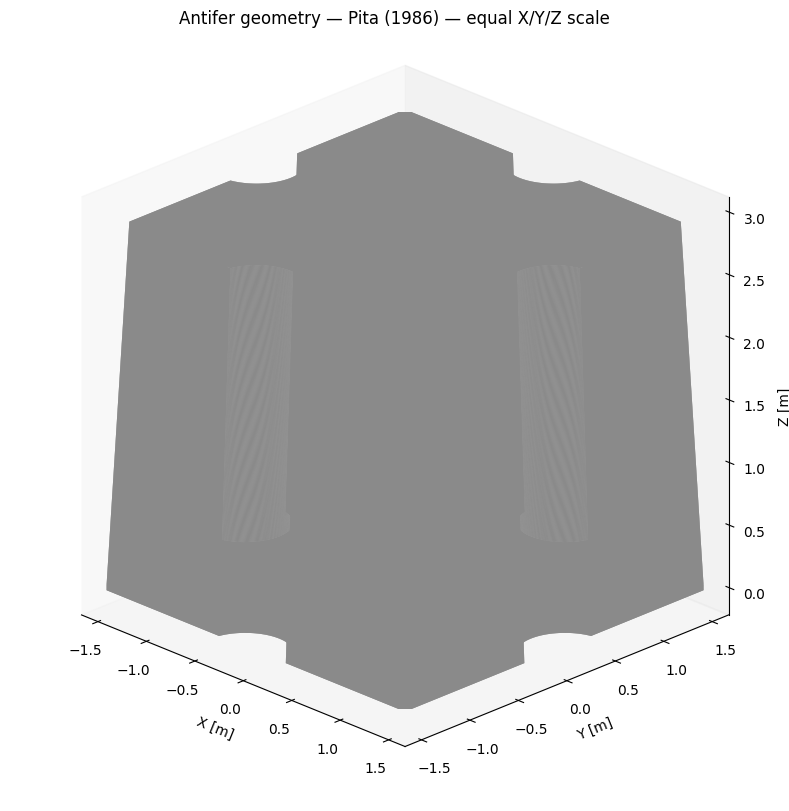

In [4]:
# =============================================================================
# MATPLOTLIB 3D VISUALISATION — EQUAL XYZ SCALE / DARKER SOLID GREY
# =============================================================================

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


def set_axes_equal_3d(ax, vertices: list[Point3], padding: float = 0.06) -> None:
    """Force identical X/Y/Z data scale in Matplotlib 3D axes."""
    xs = [p[0] for p in vertices]
    ys = [p[1] for p in vertices]
    zs = [p[2] for p in vertices]
    dx = max(xs) - min(xs)
    dy = max(ys) - min(ys)
    dz = max(zs) - min(zs)
    max_range = max(dx, dy, dz, 1.0e-12) * (1.0 + padding)
    mid_x = 0.5 * (max(xs) + min(xs))
    mid_y = 0.5 * (max(ys) + min(ys))
    mid_z = 0.5 * (max(zs) + min(zs))
    radius = 0.5 * max_range
    ax.set_xlim(mid_x - radius, mid_x + radius)
    ax.set_ylim(mid_y - radius, mid_y + radius)
    ax.set_zlim(mid_z - radius, mid_z + radius)
    ax.set_box_aspect((1.0, 1.0, 1.0))


def plot_antifer_matplotlib(brep: BrepData, elev: float = 24.0, azim: float = -45.0) -> None:
    fig = plt.figure(figsize=(9.0, 8.0), constrained_layout=True)
    ax = fig.add_subplot(111, projection="3d")

    polygons = [[brep.vertices[i] for i in face] for face in brep.faces]
    poly = Poly3DCollection(
        polygons,
        linewidths=0.0,
        edgecolors="none",
        facecolors=(0.54, 0.54, 0.54, 0.98),
        antialiaseds=True,
    )
    ax.add_collection3d(poly)

    set_axes_equal_3d(ax, brep.vertices)
    ax.set_proj_type("ortho")
    ax.set_xlabel("X [m]")
    ax.set_ylabel("Y [m]")
    ax.set_zlabel("Z [m]")
    ax.grid(False)
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(f"Antifer geometry — {brep.dimensions.profile.label} — equal X/Y/Z scale")
    plt.show()


plot_antifer_matplotlib(brep)


In [5]:
# =============================================================================
# NATIVE HTML/CANVAS INTERACTIVE VIEWER — SOLID ORTHOGRAPHIC VIEW, NO TRIANGULAR LINES
# =============================================================================

import json
import uuid
import html as _html
from IPython.display import HTML, display


def _notebook_bbox(vertices: list[Point3]) -> dict[str, float]:
    xs = [p[0] for p in vertices]
    ys = [p[1] for p in vertices]
    zs = [p[2] for p in vertices]
    return {
        "xmin": min(xs), "xmax": max(xs),
        "ymin": min(ys), "ymax": max(ys),
        "zmin": min(zs), "zmax": max(zs),
        "dx": max(xs) - min(xs),
        "dy": max(ys) - min(ys),
        "dz": max(zs) - min(zs),
    }


def antifer_canvas_viewer(
    brep: BrepData,
    width: int = 980,
    height: int = 720,
    show_edges: bool = False,
    title: str | None = None,
) -> None:
    """Display an interactive solid Antifer viewer using native HTML Canvas.

    The viewer renders the original B-rep polygon faces, not the triangulated
    export mesh. Therefore cap and side surfaces are shown as solid faces
    without visible triangular diagonals. Projection is orthographic and uses
    one common XYZ scale, so vertical and horizontal proportions are preserved.

    Controls:
        - left mouse drag: free 360° rotation;
        - right mouse drag, middle mouse drag or Shift + left drag: pan up/down/sideways;
        - mouse wheel: zoom;
        - double click: reset view.
    """
    vertices = [[float(x), float(y), float(z)] for x, y, z in brep.vertices]
    faces = [list(face) for face in brep.faces]
    bbox = _notebook_bbox(brep.vertices)
    scale = max(bbox["dx"], bbox["dy"], bbox["dz"], 1.0e-12)
    center_x = 0.5 * (bbox["xmin"] + bbox["xmax"])
    center_y = 0.5 * (bbox["ymin"] + bbox["ymax"])
    center_z = 0.5 * (bbox["zmin"] + bbox["zmax"])
    uid = "antifer_" + uuid.uuid4().hex
    title = title or f"Antifer 3D viewer — {brep.dimensions.profile.label}"

    payload_vertices = json.dumps(vertices, separators=(",", ":"))
    payload_faces = json.dumps(faces, separators=(",", ":"))
    payload_title = json.dumps(title)
    payload_show_edges = "true" if show_edges else "false"

    viewer_html = f"""
<div style="max-width:{width}px; border:1px solid #bbb; padding:10px; font-family:Arial, sans-serif; background:#f6f6f6;">
  <div style="font-weight:600; margin-bottom:6px;">{_html.escape(title)}</div>
  <canvas id="{uid}" width="{width}" height="{height}"
    style="width:100%; height:auto; background:linear-gradient(#ffffff,#eeeeee); cursor:grab; border:1px solid #ddd; touch-action:none;"></canvas>
  <div style="font-size:12px; color:#555; margin-top:6px;">
    Solid orthographic B-rep view, equal XYZ scale. Left drag = free rotation · right/middle/Shift+drag = pan up/down/sideways · wheel = zoom · double-click = reset.
  </div>
</div>
<script>
(() => {{
  const canvas = document.getElementById({json.dumps(uid)});
  const ctx = canvas.getContext('2d');
  const vertices0 = {payload_vertices};
  const faces0 = {payload_faces};
  const title = {payload_title};
  const showEdges = {payload_show_edges};
  const W = canvas.width;
  const H = canvas.height;
  const modelScale = {scale:.17g};
  const centerX = {center_x:.17g};
  const centerY = {center_y:.17g};
  const centerZ = {center_z:.17g};

  let rx = -0.58;
  let rz = 0.78;
  let zoom = 1.06;
  let panX = 0.0;
  let panY = 0.0;
  let dragging = false;
  let dragMode = 'rotate';
  let lastX = 0;
  let lastY = 0;

  function rotateNormalised(p) {{
    const cz = Math.cos(rz), sz = Math.sin(rz);
    let x1 = cz * p[0] - sz * p[1];
    let y1 = sz * p[0] + cz * p[1];
    let z1 = p[2];

    const cx = Math.cos(rx), sx = Math.sin(rx);
    let y2 = cx * y1 - sx * z1;
    let z2 = sx * y1 + cx * z1;
    return [x1, y2, z2];
  }}

  function rotatePoint(p) {{
    return rotateNormalised([
      (p[0] - centerX) / modelScale,
      (p[1] - centerY) / modelScale,
      (p[2] - centerZ) / modelScale
    ]);
  }}

  function project(p) {{
    const pixelScale = Math.min(W, H) * 0.82 * zoom;
    return [
      W * 0.5 + panX + pixelScale * p[0],
      H * 0.52 + panY - pixelScale * p[1]
    ];
  }}

  function faceNormal(a, b, c) {{
    const ux = b[0] - a[0], uy = b[1] - a[1], uz = b[2] - a[2];
    const vx = c[0] - a[0], vy = c[1] - a[1], vz = c[2] - a[2];
    let nx = uy * vz - uz * vy;
    let ny = uz * vx - ux * vz;
    let nz = ux * vy - uy * vx;
    const n = Math.hypot(nx, ny, nz) || 1.0;
    return [nx / n, ny / n, nz / n];
  }}

  function stableNormalForFace(face, verts) {{
    if (face.length < 3) return [0, 0, 1];
    const a = verts[face[0]];
    for (let i = 1; i < face.length - 1; i++) {{
      const b = verts[face[i]];
      const c = verts[face[i + 1]];
      const n = faceNormal(a, b, c);
      if (Math.hypot(n[0], n[1], n[2]) > 0.0) return n;
    }}
    return [0, 0, 1];
  }}

  function drawAxes() {{
    const axes = [
      [[-0.58,-0.58,-0.55],[-0.30,-0.58,-0.55],'X'],
      [[-0.58,-0.58,-0.55],[-0.58,-0.30,-0.55],'Y'],
      [[-0.58,-0.58,-0.55],[-0.58,-0.58,-0.27],'Z']
    ];
    ctx.font = '12px Arial';
    ctx.lineWidth = 1.1;
    for (const ax of axes) {{
      const a = project(rotateNormalised(ax[0]));
      const b = project(rotateNormalised(ax[1]));
      ctx.beginPath();
      ctx.moveTo(a[0], a[1]);
      ctx.lineTo(b[0], b[1]);
      ctx.strokeStyle = 'rgba(30,30,30,0.45)';
      ctx.stroke();
      ctx.fillStyle = 'rgba(30,30,30,0.70)';
      ctx.fillText(ax[2], b[0] + 4, b[1] - 4);
    }}
  }}

  function draw() {{
    ctx.clearRect(0, 0, W, H);
    const verts = vertices0.map(rotatePoint);
    const projected = verts.map(project);
    const light = [0.28, -0.45, 0.84];
    const len = Math.hypot(light[0], light[1], light[2]);
    light[0] /= len; light[1] /= len; light[2] /= len;
    const drawFaces = [];

    for (const face of faces0) {{
      if (face.length < 3) continue;
      const n = stableNormalForFace(face, verts);
      const dot = n[0] * light[0] + n[1] * light[1] + n[2] * light[2];
      const shadeRaw = Math.abs(dot);
      const shade = Math.round(118 + 74 * shadeRaw);  // darker grey than previous version
      const avgZ = face.reduce((s, idx) => s + verts[idx][2], 0.0) / face.length;
      drawFaces.push({{face, avgZ, shade}});
    }}

    drawFaces.sort((a, b) => a.avgZ - b.avgZ);

    for (const f of drawFaces) {{
      const face = f.face;
      const p0 = projected[face[0]];
      const fill = `rgb(${{f.shade}},${{f.shade}},${{f.shade}})`;
      ctx.beginPath();
      ctx.moveTo(p0[0], p0[1]);
      for (let i = 1; i < face.length; i++) {{
        const p = projected[face[i]];
        ctx.lineTo(p[0], p[1]);
      }}
      ctx.closePath();
      ctx.fillStyle = fill;
      ctx.fill('nonzero');

      // Same-colour stroke hides anti-aliased seams between adjacent B-rep faces;
      // it does not draw export-mesh triangular diagonals.
      ctx.strokeStyle = fill;
      ctx.lineWidth = 0.85;
      ctx.stroke();

      if (showEdges) {{
        ctx.strokeStyle = 'rgba(0,0,0,0.18)';
        ctx.lineWidth = 0.55;
        ctx.stroke();
      }}
    }}

    drawAxes();
    ctx.fillStyle = 'rgba(0,0,0,0.72)';
    ctx.font = '12px Arial';
    ctx.fillText(title, 12, 22);
  }}

  function pointerMode(ev) {{
    if (ev.shiftKey || ev.button === 1 || ev.button === 2) return 'pan';
    return 'rotate';
  }}

  canvas.addEventListener('contextmenu', (ev) => ev.preventDefault());

  canvas.addEventListener('pointerdown', (ev) => {{
    dragging = true;
    dragMode = pointerMode(ev);
    lastX = ev.clientX;
    lastY = ev.clientY;
    canvas.setPointerCapture(ev.pointerId);
    canvas.style.cursor = dragMode === 'pan' ? 'move' : 'grabbing';
  }});

  canvas.addEventListener('pointerup', (ev) => {{
    dragging = false;
    canvas.releasePointerCapture(ev.pointerId);
    canvas.style.cursor = 'grab';
  }});

  canvas.addEventListener('pointercancel', () => {{
    dragging = false;
    canvas.style.cursor = 'grab';
  }});

  canvas.addEventListener('pointermove', (ev) => {{
    if (!dragging) return;
    const dx = ev.clientX - lastX;
    const dy = ev.clientY - lastY;
    lastX = ev.clientX;
    lastY = ev.clientY;

    if (dragMode === 'pan') {{
      panX += dx;
      panY += dy;
    }} else {{
      rz += dx * 0.008;
      rx += dy * 0.008;
    }}
    draw();
  }});

  canvas.addEventListener('wheel', (ev) => {{
    ev.preventDefault();
    zoom *= Math.exp(-ev.deltaY * 0.001);
    zoom = Math.max(0.18, Math.min(8.0, zoom));
    draw();
  }}, {{passive:false}});

  canvas.addEventListener('dblclick', () => {{
    rx = -0.58;
    rz = 0.78;
    zoom = 1.06;
    panX = 0.0;
    panY = 0.0;
    draw();
  }});

  draw();
}})();
</script>
"""
    display(HTML(viewer_html))


antifer_canvas_viewer(brep, show_edges=False)


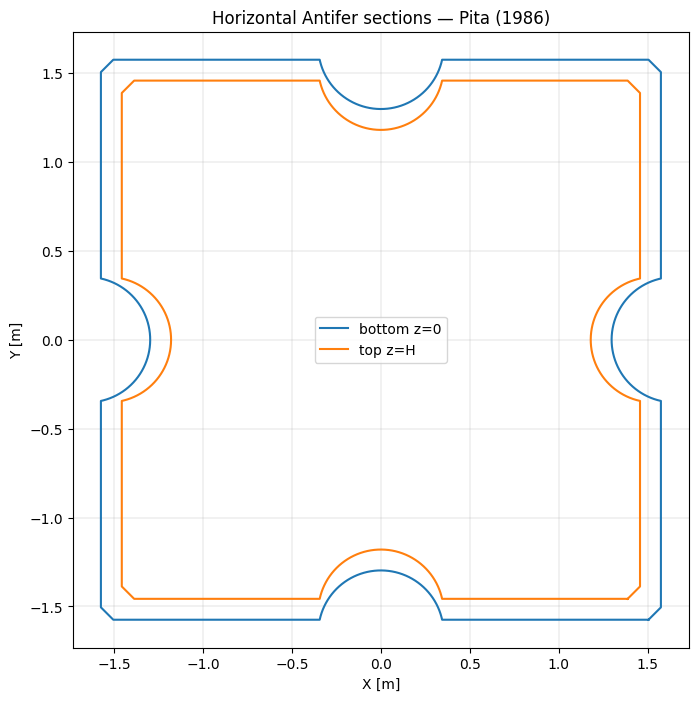

In [6]:
# =============================================================================
# OPTIONAL PLAN VIEW OF TOP AND BOTTOM SECTIONS
# =============================================================================


def plot_plan_sections(brep: BrepData) -> None:
    d = brep.dimensions
    bottom = section_2d(d.A, d.D, d.R, d.groove_centre_offset)
    top = section_2d(d.B, d.D, d.R, d.groove_centre_offset)
    fig, ax = plt.subplots(figsize=(8, 8))
    for section, label in [(bottom, "bottom z=0"), (top, "top z=H")]:
        xs = [p[0] for p in section] + [section[0][0]]
        ys = [p[1] for p in section] + [section[0][1]]
        ax.plot(xs, ys, label=label)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("X [m]")
    ax.set_ylabel("Y [m]")
    ax.set_title(f"Horizontal Antifer sections — {d.profile.label}")
    ax.grid(True, linewidth=0.25)
    ax.legend()
    plt.show()


plot_plan_sections(brep)


In [7]:
# =============================================================================
# EXPORT IFC + STL + OBJ + DXF + OUTPUT REPORT
# =============================================================================

# This cell writes the notebook deliverables to OUTPUT_FOLDER.
# DXF export is ACIS-backed 3DSOLID through ezdxf, not a simplified 3DFACE shell.
# In a notebook kernel, install missing export dependencies with:
#     %pip install ezdxf trimesh pillow

from pathlib import Path

output_folder = str(OUTPUT_FOLDER)
Path(output_folder).mkdir(parents=True, exist_ok=True)

try:
    ifc_path, stl_path, obj_path, dxf_path, output_text_path, export_brep = create_ifc_stl_obj_and_dxf_files(
        output_folder,
        W_kN,
        Wc_kN_m3,
        GEOMETRY_PROFILE,
    )
    print("Files generated successfully:")
    print(f"IFC: {ifc_path}")
    print(f"STL: {stl_path}")
    print(f"OBJ: {obj_path}")
    print(f"DXF: {dxf_path}")
    print(f"TXT: {output_text_path}")
except ModuleNotFoundError as exc:
    print("Export failed because a required production dependency is missing.")
    print("Install the same dependencies used by script.py, then rerun this cell:")
    print("    python -m pip install ezdxf trimesh pillow")
    print(f"Missing module: {exc.name}")
    raise


Files generated successfully:
IFC: antifer_notebook_output\antifer_pita1986_680kN_Wc27p2kNm3.ifc
STL: antifer_notebook_output\antifer_pita1986_680kN_Wc27p2kNm3.stl
OBJ: antifer_notebook_output\antifer_pita1986_680kN_Wc27p2kNm3.obj
DXF: antifer_notebook_output\antifer_pita1986_680kN_Wc27p2kNm3.dxf
TXT: antifer_notebook_output\output.txt


## Notes on interpretation and notebook use

- The Pita option uses the adopted historical dimensional convention and the governing geometric coefficient \(V/H^3 = 1.024700000000\).
- The Carvalho option uses a volume-normalised coefficient convention with the same geometric topology and groove formulation, giving \(V/H^3 = 1.000000\).
- The generated solid is built from explicit boundary loops, not imported from a CAD template.
- The B-rep groove sampling is area-preserving at the fixed production arc resolution.
- The visualisation renders B-rep polygon faces directly, so it is intentionally independent from the triangular export mesh.
- The export cell writes IFC, STL, OBJ, DXF and `output.txt` to `OUTPUT_FOLDER`.
- Full DXF export requires `ezdxf` and `trimesh` in the active notebook kernel.
- The notebook is run cell-by-cell in the active kernel; the export cell creates the deliverables.
